# EDA Overview - Final Dataset

This notebook provides a general overview of the final dataset used in the early warning model for CERF conflict allocations. The goal is to understand the structure, coverage, and quality of the data before conducting variable-specific analyses.

The dataset integrates multiple sources (ACLED, IDMC, EconAI, INFORM, HDX Signals, and CERF)  into a single panel with country-month observations. This overview covers:

- Dataset dimensions and structure
- Temporal and geographic coverage
- Missing values by variable and source
- Distribution of the target variable (`allocation-eligible`)

In [1]:
import os
import pandas as pd
import numpy as np

# Cambiamos read_csv por read_parquet y actualizamos el nombre del fichero
df = pd.read_parquet('../data_clean/complete_dataset.parquet')
print(f"Data loaded successfully: {df.shape}")

ModuleNotFoundError: No module named 'pandas'

In [21]:
# Dataset dimensions
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")

Rows: 17,600
Columns: 25

Column types:
float64    22
int64       2
str         1
Name: count, dtype: int64


In [22]:
#Index structure
print(f"Countries: {df.index.get_level_values('iso3').nunique()}")
print(f"Date range: {df.index.get_level_values('month').min()} to {df.index.get_level_values('month').max()}")
print(f"Unique months: {df.index.get_level_values('month').nunique()}")

Countries: 176
Date range: 2018-01-01 00:00:00 to 2026-04-01 00:00:00
Unique months: 100


In [23]:
# See all columns without truncation
pd.set_option('display.max_rows', None)
print(df.columns.tolist())

['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12', 'INFORM', 'VU', 'CC', 'HA', 'fatalities', 'event_count', 'notes_acled', 'Battles', 'Explosions/Remote violence', 'Protests', 'Riots', 'Strategic developments', 'Violence against civilians', 'hdx_value', 'hdx_alert_High concern', 'hdx_alert_Medium concern', 'monthly_displacement', 'rolling_3m_displacements', 'allocation-eligible', 'target_2m', 'start_conflict']


In [24]:
# Distribution of allocation-eligible
print("=== Allocation-Eligible Distribution ===")
print(df['allocation-eligible'].value_counts())
print(f"\nProportion:")
print((df['allocation-eligible'].value_counts(normalize=True) * 100).round(2))

# Countries most frequently allocation-eligible
print("\n=== Top 20 Countries by Allocation-Eligible Months ===")
print(df[df['allocation-eligible'] == 1].groupby('iso3').size().sort_values(ascending=False).head(20))

=== Allocation-Eligible Distribution ===
allocation-eligible
0    16973
1      627
Name: count, dtype: int64

Proportion:
allocation-eligible
0    96.44
1     3.56
Name: proportion, dtype: float64

=== Top 20 Countries by Allocation-Eligible Months ===
iso3
COD    97
ETH    60
MMR    47
SYR    47
SDN    47
BFA    42
AFG    38
CAF    34
SSD    32
SOM    28
PSE    25
NGA    20
MLI    17
HTI    14
MOZ    13
YEM    12
PHL    10
NER     9
LBN     6
UKR     5
dtype: int64


## Variable Dictionary by Source

### ACLED (Structured)
Variables: `fatalities`, `event_count`, `Battles`, `Explosions/Remote violence`,
`Protests`, `Riots`, `Strategic developments`, `Violence against civilians`

Source: `acled_data_wrangled.csv`, aggregated by country-month.
`fatalities` is the monthly sum of conflict deaths; `event_count` is the total
number of recorded conflict events. The remaining columns disaggregate event
counts by type of conflict activity.

<hr>

### ACLED Notes (NLP)
Variables: `notes_acled`

Source: Extracted from the `notes` field of ACLED events. Contains the raw
text of conflict event reports aggregated by country-month, used for
keyword-based feature extraction.

<hr>

### HDX Signals
Variables: `hdx_value`, `hdx_alert_High concern`, `hdx_alert_Medium concern`

Source: `hdx_signals.csv`. `hdx_value` is the numerical value of the alert.
`hdx_alert_High concern` and `hdx_alert_Medium concern` are binary indicators
for the corresponding alert level in a given country-month.

<hr>

### IDMC (Internal Displacement Monitoring Centre)
Variables: `monthly_displacement`, `rolling_3m_displacements`

Source: `idmc_conflict_wrangled.csv`, filtered to conflict-induced displacement
only and aggregated from daily to monthly observations.

<hr>

### EconAI
Variables: `risk_3`, `risk_12`, `logfat_risk_3`, `logfat_risk_12`

Source: EconAI conflict forecasting model. `risk_3` and `risk_12` are predicted
probabilities of armed conflict onset at 3 and 12-month horizons.
`logfat_risk_3` and `logfat_risk_12` are predicted fatalities on a log scale.

<hr>

### INFORM Risk Index
Variables: `INFORM`, `VU`, `CC`, `HA`

Source: INFORM Risk Index. `INFORM` is the composite risk score;
`VU` = Vulnerability, `CC` = Coping Capacity, `HA` = Hazard & Exposure.

<hr>

### Target and Constructed Variables
Variables: `allocation-eligible`, `target_2m`, `start_conflict`

`allocation-eligible` is 1 if the country meets the CERF displacement threshold
(50,000+ new IDPs over 3 months). `target_2m` is the model target: 1 at the
start of an allocation-eligible period in the next 2 months, NaN during the
period, and 0 otherwise. `start_conflict` marks the onset of a new conflict period.

# EXPLORATORY DATA ANALYSIS

In this notebook we are going to analyse all the datasets that we are working with, in order to see not only the behaviour of the variables but also how they interact with our target variable, so that we can later perform a good feature engineering.

In [25]:
import os
import pandas as pd
import numpy as np

# Cambiamos read_csv por read_parquet y actualizamos el nombre del fichero
df = pd.read_parquet('../data_clean/complete_dataset.parquet')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (17600, 25)


In [5]:
df.head()

risk_3   risk_12  logfat_risk_3  logfat_risk_12  INFORM  \
iso3 month                                                                   
AFG  2018-01-01  0.494067  0.695173       7.690273        8.159422     7.8   
     2018-02-01  0.506174  0.726673       7.775459        8.036293     7.8   
     2018-03-01  0.493192  0.713110       7.890279        8.250671     7.8   
     2018-04-01  0.469532  0.713219       8.010917        8.123474     7.8   
     2018-05-01  0.483328  0.696213       8.044887        8.216409     7.7   

                  VU   CC   HA  fatalities  event_count  ...  \
iso3 month                                               ...   
AFG  2018-01-01  7.1  7.7  8.8      2822.0       1145.0  ...   
     2018-02-01  7.1  7.7  8.8      1829.0        920.0  ...   
     2018-03-01  7.1  7.7  8.8      2286.0        976.0  ...   
     2018-04-01  7.1  7.7  8.8      2794.0       1245.0  ...   
     2018-05-01  7.1  7.5  8.7      4264.0       1482.0  ...   

                Strategic developments  Violence against civilians  hdx_value  \
iso3 month                                                                      
AFG  2018-01-01                   37.0                        38.0        0.0   
     2018-02-01                   23.0                        26.0        1.0   
     2018-03-01                   14.0                        17.0        0.0   
     2018-04-01                   22.0                        22.0        0.0   
     2018-05-01                   18.0                        34.0        2.0   

                 hdx_alert_High concern  hdx_alert_Medium concern  \
iso3 month                                                          
AFG  2018-01-01                     0.0                       0.0   
     2018-02-01                     0.0                       1.0   
     2018-03-01                     0.0                       0.0   
     2018-04-01                     0.0                       0.0   
     2018-05-01                     1.0                       0.0   

                 monthly_displacement  rolling_3m_displacements  \
iso3 month                                                        
AFG  2018-01-01           7456.583577               7456.583577   
     2018-02-01          13918.956010              21375.539587   
     2018-03-01          15410.272726              36785.812313   
     2018-04-01          17198.881440              46528.110176   
     2018-05-01          39769.719735              72378.873901   

                 allocation-eligible  target_2m  start_conflict  
iso3 month                                                       
AFG  2018-01-01                    0        0.0               0  
     2018-02-01                    0        0.0               0  
     2018-03-01                    0        1.0               0  
     2018-04-01                    0        1.0               0  
     2018-05-01                    1        NaN               1  

[5 rows x 25 columns]

In [2]:
df.reset_index(inplace=True)
df.columns.tolist()

['iso3',
 'month',
 'risk_3',
 'risk_12',
 'logfat_risk_3',
 'logfat_risk_12',
 'INFORM',
 'VU',
 'CC',
 'HA',
 'fatalities',
 'event_count',
 'notes_acled',
 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians',
 'hdx_value',
 'hdx_alert_High concern',
 'hdx_alert_Medium concern',
 'monthly_displacement',
 'rolling_3m_displacements',
 'allocation-eligible',
 'target_2m',
 'start_conflict']

### ACLED — Armed Conflict Location & Event Data
ACLED records political violence and conflict events at the country-day level, capturing fatalities, event counts, and the nature of conflict activity through the conflict type and the notes section. We expect countries with higher fatality counts and more frequent conflict events to be more likely to meet the CERF allocation-eligibility criteria, as intense conflict is a primary driver of internal displacement. The type of conflict also matters: civilian-targeted violence and heavy warfare are expected to be stronger predictors of displacement than social unrest or political violence.

#### Part 1: Univariate Analysis
This section describes the distribution and coverage of ACLED variables independently of the target variable. The goal is to understand the data quality, detect outliers, and identify patterns in conflict activity across countries and time.

In [10]:
# ACLED variables
acled_cols = ['fatalities',	'event_count', 'notes_acled', 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians']

df[acled_cols].describe().round(2)

,fatalities,event_count,Battles,Explosions/Remote violence,Protests,Riots,Strategic developments,Violence against civilians
count,17600.00,17600.00,17600.00,17600.00,17600.00,17600.00,17600.00,17600.00
mean,88.39,144.66,22.79,26.02,60.82,8.51,10.97,15.55
std,478.68,405.88,112.36,206.78,180.22,34.38,36.08,51.83
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00
50%,0.00,20.00,0.00,0.00,8.00,1.00,1.00,0.00
75%,11.00,102.00,3.00,0.00,42.00,4.00,5.00,6.00
max,27661.00,7059.00,2949.00,4446.00,6584.00,874.00,526.00,619.00


In [11]:
# Missing values
print("Missing values:")
print(df[acled_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[acled_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
fatalities                    0
event_count                   0
notes_acled                   0
Battles                       0
Explosions/Remote violence    0
Protests                      0
Riots                         0
Strategic developments        0
Violence against civilians    0
dtype: int64

Missing percentage:
fatalities                    0.0
event_count                   0.0
notes_acled                   0.0
Battles                       0.0
Explosions/Remote violence    0.0
Protests                      0.0
Riots                         0.0
Strategic developments        0.0
Violence against civilians    0.0
dtype: float64


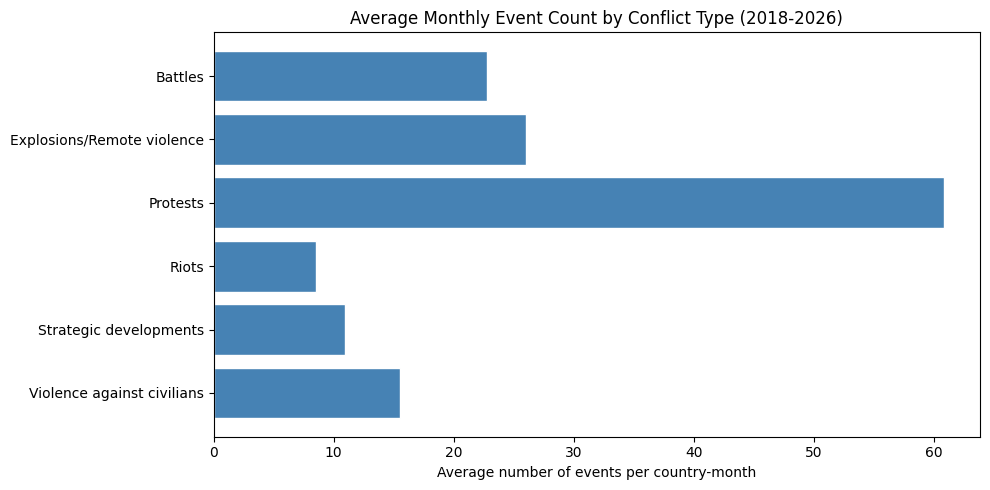

In [12]:
import matplotlib.pyplot as plt
import numpy as np

event_cols = ['Battles', 'Explosions/Remote violence', 'Protests', 
              'Riots', 'Strategic developments', 'Violence against civilians']

means = df[event_cols].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(means.index[::-1], means.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Average Monthly Event Count by Conflict Type (2018-2026)')
ax.set_xlabel('Average number of events per country-month')
plt.tight_layout()
plt.show()

The study of the notes explaining the events will be based more on the literature review, not in this notebook, so until now we are only exploring `fatalities`, `event_count` and `Battles`, `Explosions/Remote violence`, `Protests`, `Riots`, `Strategic developments` and `Violence against civilians`.

In [13]:
acled_cols = ['fatalities',	'event_count', 'notes_acled', 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians']

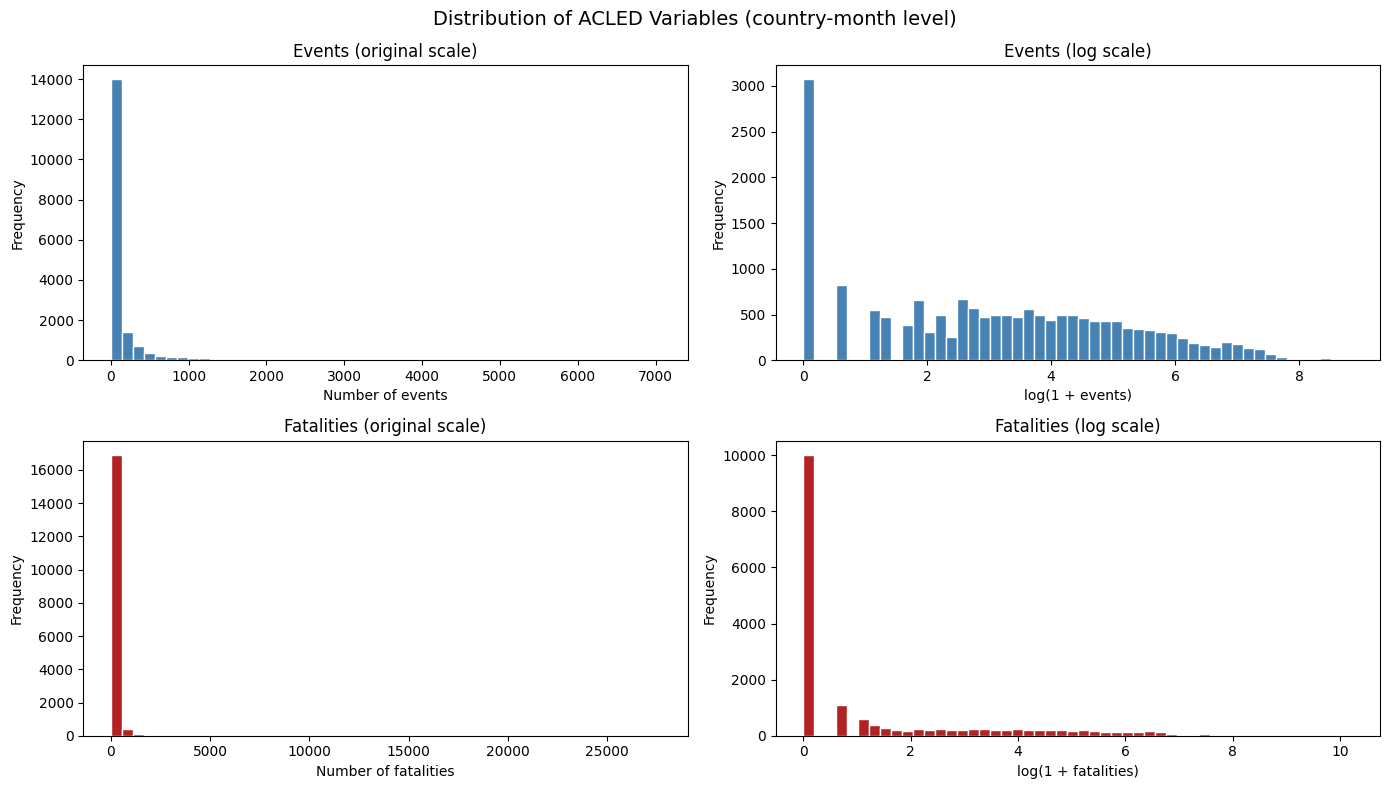

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of ACLED Variables (country-month level)', fontsize=14)

# Events - original
axes[0, 0].hist(df['event_count'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Events (original scale)')
axes[0, 0].set_xlabel('Number of events')
axes[0, 0].set_ylabel('Frequency')

# Events - log
axes[0, 1].hist(np.log1p(df['event_count']), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Events (log scale)')
axes[0, 1].set_xlabel('log(1 + events)')
axes[0, 1].set_ylabel('Frequency')

# Fatalities - original
axes[1, 0].hist(df['fatalities'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Fatalities (original scale)')
axes[1, 0].set_xlabel('Number of fatalities')
axes[1, 0].set_ylabel('Frequency')

# Fatalities - log
axes[1, 1].hist(np.log1p(df['fatalities']), bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Fatalities (log scale)')
axes[1, 1].set_xlabel('log(1 + fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Both variables show a strong right-skewed distribution at the country-month level. For `event_count`, most country-months record fewer than 500 events, with a few extreme cases reaching over 8,000. For `fatalities`, the skew is even more pronounced, over half of all country-months report zero fatalities, meaning that conflict-related deaths are concentrated in a small number of countries and time periods. Even after applying the log(1+x) transformation, the spike at zero remains dominant for fatalities, confirming that conflict is a rare and concentrated phenomenon in this dataset. This is consistent with the low share of allocation-eligible observations in the target variable.

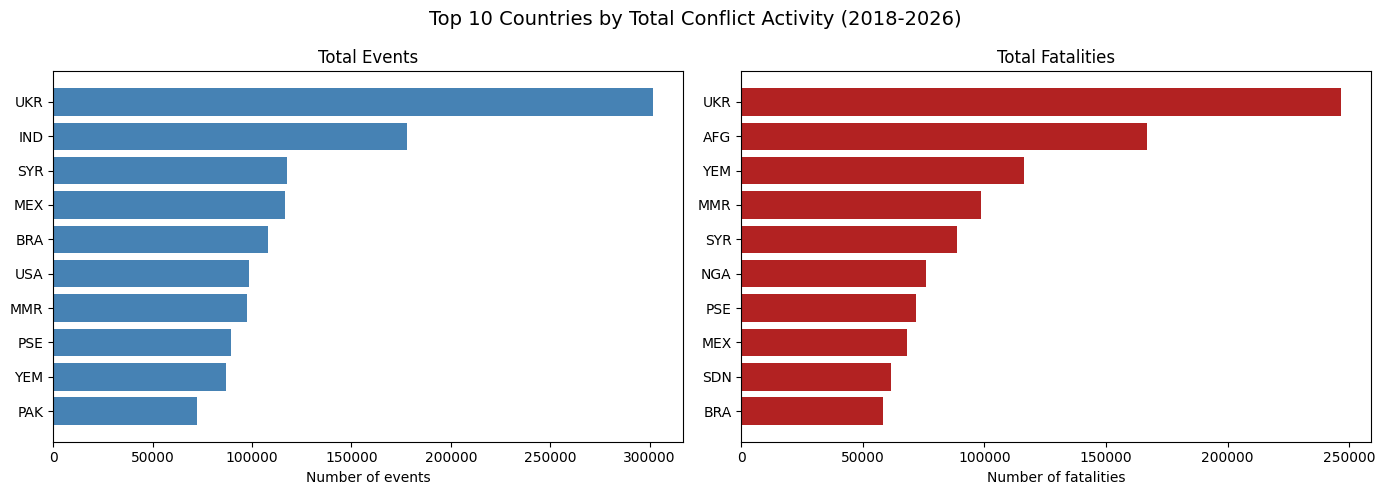

In [15]:
# Top 10 countries by total events and fatalities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 10 Countries by Total Conflict Activity (2018-2026)', fontsize=14)

# Top 10 by events
top_events = df.groupby('iso3')['event_count'].sum().nlargest(10)
axes[0].barh(top_events.index[::-1], top_events.values[::-1], color='steelblue')
axes[0].set_title('Total Events')
axes[0].set_xlabel('Number of events')

# Top 10 by fatalities
top_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10)
axes[1].barh(top_fatalities.index[::-1], top_fatalities.values[::-1], color='firebrick')
axes[1].set_title('Total Fatalities')
axes[1].set_xlabel('Number of fatalities')

plt.tight_layout()
plt.show()

The charts display the top 10 countries by total accumulated events and fatalities over the study period. Ukraine ranks first in both lists, which is expected given the scale of conflict following the Russian invasion in 2022. While several countries appear in both rankings, the order differs, suggesting that conflict frequency and fatalities do not always go hand in hand. Some countries record many events with relatively few deaths, while others concentrate high fatality counts in fewer but more deadly incidents. This confirms that both variables capture different dimensions of conflict.

In [16]:
# Extract year from month
df['year'] = pd.to_datetime(df['month']).dt.year

# Average monthly events and fatalities by year
yearly_avg = df.groupby('year')[['event_count', 'fatalities']].mean().round(2)
yearly_avg.columns = ['Avg Monthly Events', 'Avg Monthly Fatalities']
yearly_avg

,Avg Monthly Events,Avg Monthly Fatalities
year,,
2018,100.61,84.72
2019,109.25,73.38
2020,126.99,66.14
2021,137.95,75.95
2022,151.51,80.34
2023,166.12,94.69
2024,185.64,117.96
2025,192.73,113.34
2026,104.10,90.05


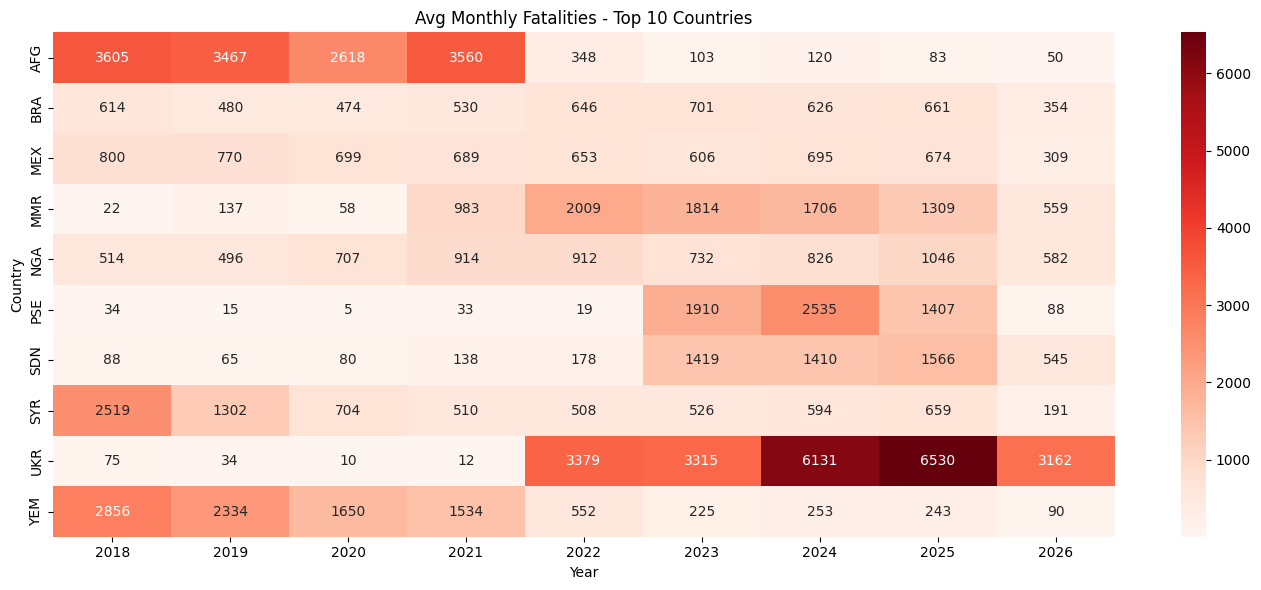

In [17]:
import seaborn as sns

# Top 10 countries by total fatalities
top10_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10).index

yearly_country = df[df['iso3'].isin(top10_fatalities)].groupby(['year', 'iso3'])['fatalities'].mean().round(2)

pivot_fatalities = yearly_country.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_fatalities, cmap='Reds', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Fatalities - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap displays the average monthly fatalities for the 10 countries with the highest cumulative death over the study period (2018-2026). These countries are concentrated in conflict-prone regions: the Middle East (Syria, Yemen, Palestine), Sub-Saharan Africa (Nigeria, Sudan), Southeast Asia (Myanmar), Eastern Europe (Ukraine), and South Asia (Afghanistan). Several patterns stand out. Afghanistan recorded the highest monthly averages between 2018 and 2021 (above 3,000 deaths per month), dropping sharply after the Taliban takeover in August 2021. Ukraine shows the opposite trend , nearly no fatalities before 2022, then surging to over 6,000 monthly deaths by 2024 following the Russian invasion. Palestine (PSE) follows a similar pattern, remaining low until 2023 when the Gaza conflict began. Mexico is a notable case, it consistently appears in the top 10 despite not being associated with conventional armed conflict. Its presence reflects ongoing cartel-related violence, which ACLED classifies as political violence, resulting in hundreds of fatalities every month throughout the entire period.

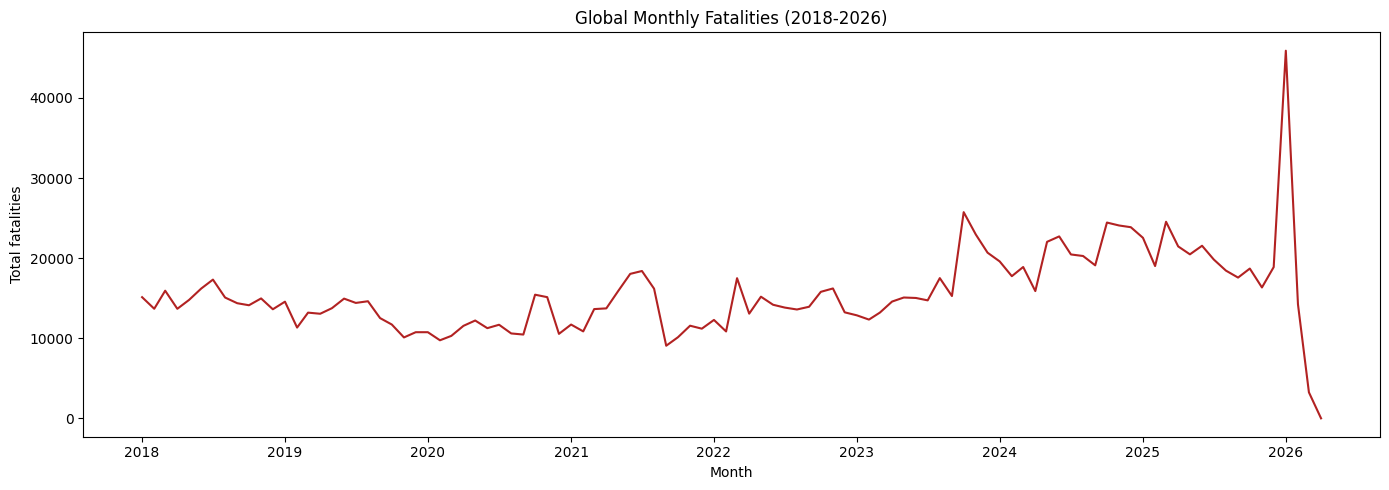

In [18]:
# Global monthly fatalities over time
global_monthly = df.groupby('month')['fatalities'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(global_monthly['month']), global_monthly['fatalities'], 
        color='firebrick', linewidth=1.5)
ax.set_title('Global Monthly Fatalities (2018-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Total fatalities')
plt.tight_layout()
plt.show()

In [19]:
# Identify which country drives the 2026 spike
spike_2026 = df[pd.to_datetime(df['month']).dt.year == 2026].groupby('iso3')['fatalities'].sum().nlargest(10)
print(spike_2026)

iso3
IRN    28136.0
UKR    12649.0
NGA     2330.0
MMR     2237.0
SDN     2179.0
SOM     1672.0
BRA     1415.0
ETH     1274.0
MEX     1235.0
PAK     1052.0
Name: fatalities, dtype: float64


The global monthly fatalities series shows a relatively stable baseline between 2018 and 2022, ranging between 10,000 and 20,000 deaths per month. From 2023 onward, a clear upward trend emerges, driven by the simultaneous escalation of multiple active conflicts ,particularly Ukraine, Sudan, and Gaza  pushing monthly totals consistently above 20,000. The sharp spike in early 2026 is largely explained by Iran (IRN), which accumulates nearly 29,000 fatalities in the first months of the year, far above its historical levels. This anomaly should be interpreted with caution, as the dataset only covers up to April 2026 and recent observations may reflect incomplete or retroactively corrected ACLED records rather than a sudden escalation of conflict. In general, the series confirms that global conflict intensity has increased over the study period, with the post-2022 period being notably more lethal than the years prior.

#### Part 2: Bivariate Analysis

This section examines how ACLED variables behave in relation to the target variable `allocation-eligible`. The goal is to assess whether conflict frequency and fatalities are systematically higher in country-months where the CERF allocation criteria are met, which would support their use as predictors in the early warning model.

In [20]:
# Mean fatalities by allocation-eligible
df.groupby('allocation-eligible')['fatalities'].mean().round(2)

allocation-eligible
0     55.19
1    986.97
Name: fatalities, dtype: float64

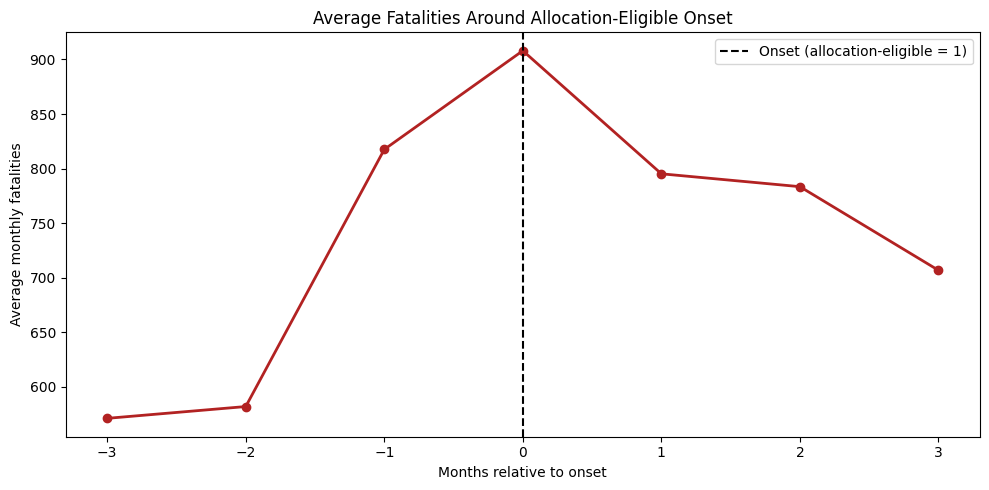

In [21]:
# Window around allocation-eligible onset
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Find months where allocation-eligible turns 1 (onset)
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

# Build window of -3 to +3 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-3, 4):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

To assess whether conflict fatalities anticipate humanitarian crises, we constructed a event window around each allocation-eligible onset. An onset is defined as the first month in which a country transitions from non-eligible to eligible status. For each onset observed in the dataset, we extracted fatality values from 3 months before to 3 months after, then averaged across all onsets globally.

The chart reveals a clear upward trend in the months preceding the onset. Average monthly fatalities rise from approximately 580 deaths at t-3 to nearly 1,000 at t=0, the onset month itself. After the onset, fatalities gradually decline but remain elevated, suggesting that conflict intensity persists even after the crisis is officially recognized. This pattern confirms that fatalities carry predictive signal ahead of the onset of allocation-eligible periods, supporting the inclusion of ACLED fatality data as a predictor in the early warning model.

In [22]:
# Check number of onsets and where they occur
print(f"Total onsets detected: {len(onset)}")
print(f"\nOnsets by year:")
print(onset['month'].dt.year.value_counts().sort_index())
print(f"\nOnsets by country:")
print(onset['iso3'].value_counts().head(20))

Total onsets detected: 106

Onsets by year:
month
2018     7
2019     7
2020     7
2021     9
2022    12
2023    18
2024    19
2025    23
2026     4
Name: count, dtype: int64

Onsets by country:
iso3
ETH    9
SYR    9
CAF    7
AFG    6
PHL    6
SOM    6
NGA    5
SDN    5
HTI    4
LBN    4
MLI    4
PSE    4
SSD    4
BFA    3
MOZ    3
NER    3
CMR    2
IRN    2
KHM    2
MMR    2
Name: count, dtype: int64


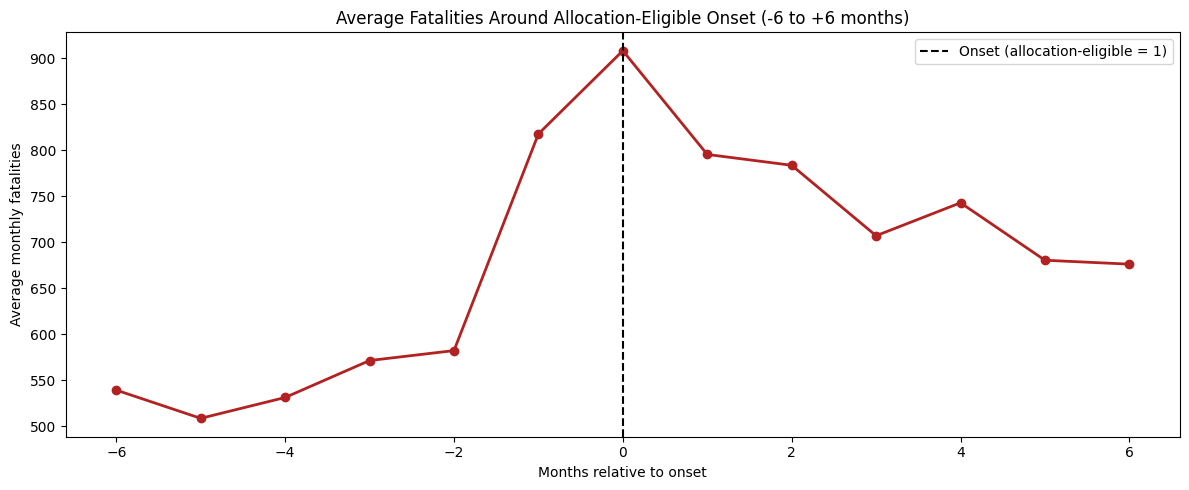

In [23]:
# Build window of -6 to +6 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

Expanding the window to 6 months before and after the onset reveals that fatalities remain relatively stable between t-6 and t-3, moving around 530-580 deaths per month. The sharpest increase occurs between t-2 and t=0, where the average jumps from approximately 620 to nearly 1,000 fatalities, suggesting that the predictive signal in fatalities is concentrated in the 2-3 months immediately preceding the onset rather than further in advance. This has two important implications for the model. First, short lags (1-2 months) are likely to be more informative than longer ones. Second, fatalities behave as a late warning signal, useful for detection but with limited anticipation capacity. This is consistent with the 2-month prediction horizon of the target variable `target_2m`.



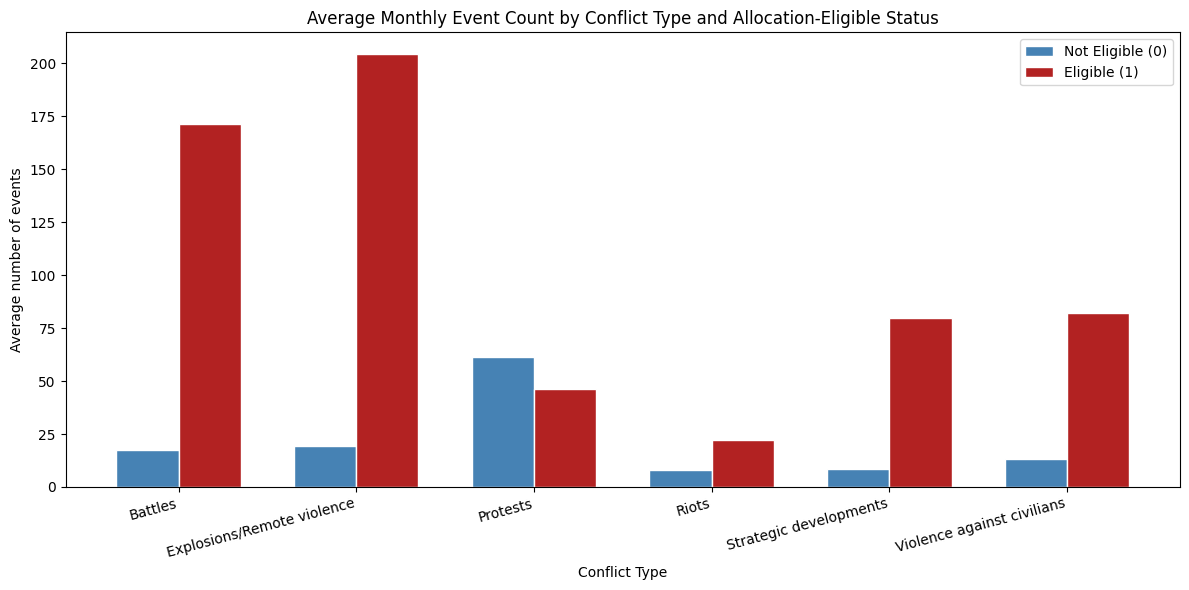

In [24]:
event_cols = ['Battles', 'Explosions/Remote violence', 'Protests', 
              'Riots', 'Strategic developments', 'Violence against civilians']

# Mean by allocation-eligible
means_by_group = df.groupby('allocation-eligible')[event_cols].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(event_cols))
width = 0.35

ax.bar(x - width/2, means_by_group.loc[0], width, label='Not Eligible (0)', color='steelblue', edgecolor='white')
ax.bar(x + width/2, means_by_group.loc[1], width, label='Eligible (1)', color='firebrick', edgecolor='white')

ax.set_title('Average Monthly Event Count by Conflict Type and Allocation-Eligible Status')
ax.set_xlabel('Conflict Type')
ax.set_ylabel('Average number of events')
ax.set_xticks(x)
ax.set_xticklabels(event_cols, rotation=15, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

Although protests are the most frequent conflict event globally, they show lower average counts among allocation-eligible country-months compared to non-eligible ones. In contrast, Battles, Explosions/Remote violence, Violence against civilians, and Strategic developments are significantly higher among eligible countries , in some cases more than 10 times higher. This confirms that displacement-triggering conflict is not about frequency but about intensity and type. Indiscriminate and direct violence against populations is what drives mass displacement and ultimately determines CERF allocation eligibility.

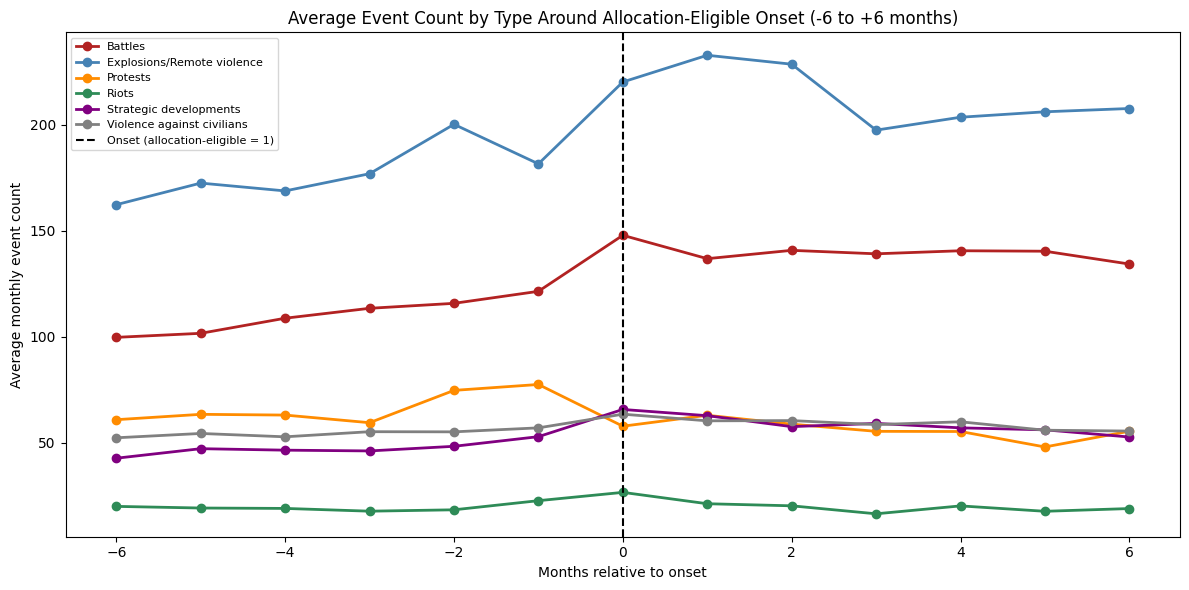

In [50]:
# Window around onset for all conflict types
event_types = ['Battles', 'Explosions/Remote violence', 'Protests', 
               'Riots', 'Strategic developments', 'Violence against civilians']

windows_events = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            entry = {'months_to_onset': t}
            for col in event_types:
                entry[col] = match[col].values[0]
            windows_events.append(entry)

window_df_events = pd.DataFrame(windows_events)
avg_events = window_df_events.groupby('months_to_onset')[event_types].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Battles': 'firebrick',
    'Explosions/Remote violence': 'steelblue',
    'Protests': 'darkorange',
    'Riots': 'seagreen',
    'Strategic developments': 'purple',
    'Violence against civilians': 'gray'
}

for col in event_types:
    ax.plot(avg_events.index, avg_events[col], marker='o', label=col, color=colors[col], linewidth=2)

ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Event Count by Type Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly event count')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

We can see an interesting pattern here. The average event count for explosions/ remote violence and battles is quite high, compared to other type of conflicts, and shows an increasing trend in months before the crisis, specially one month before suggesting we should pay more attention to short term changes. Also, explosions/remote violence and battles increase significantly after the crisis. The other type of conflicts show a lower average level but still we can see that a month before the crisis, there is a small increase, except for protests, that decreases in the crisis, which is expected.

### IDMC — Internal Displacement Monitoring Centre

IDMC tracks conflict-induced internal displacements at the country-day level, aggregated here to country-month. `monthly_displacement` captures the number of new internally displaced persons (IDPs) registered each month due to conflict. This variable is central to the project as it directly feeds into the construction of `allocation-eligible`, a country meets the CERF criteria when it accumulates 50,000 or more new displacements over a 3-month period. For this reason.

In [25]:
# Descriptive statistics - monthly displacement
print(df['monthly_displacement'].describe().round(2))
print(f"\nMissing values: {df['monthly_displacement'].isnull().sum()}")
print(f"Missing percentage: {(df['monthly_displacement'].isnull().sum() / len(df) * 100).round(2)}%")

count      17600.00
mean        5017.34
std        59018.74
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      4000000.00
Name: monthly_displacement, dtype: float64

Missing values: 0
Missing percentage: 0.0%


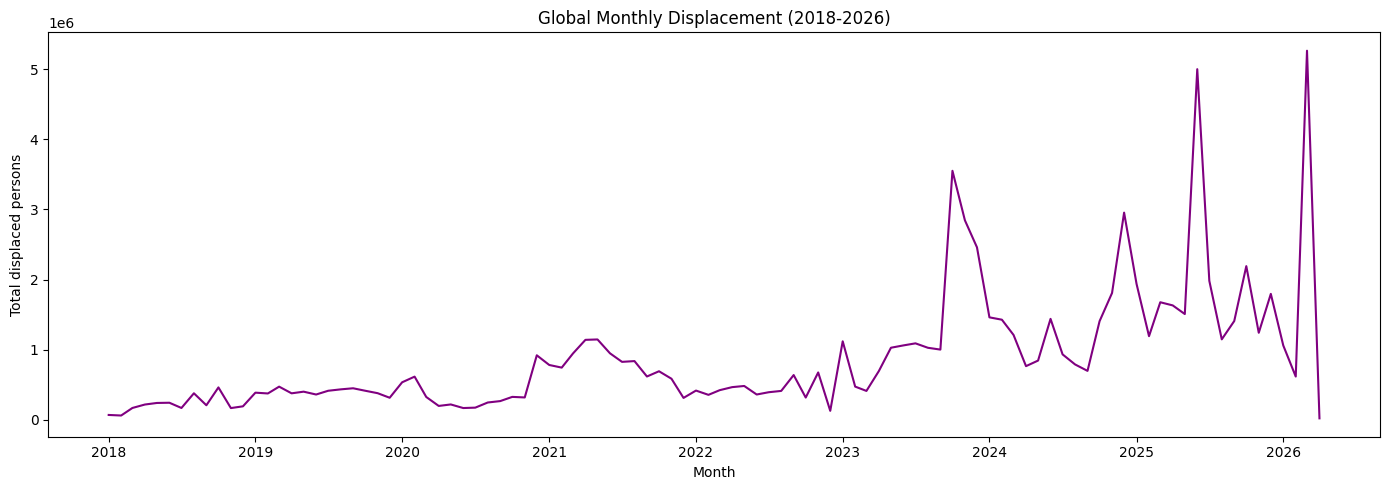

In [51]:
# Global monthly displacement over time
global_monthly_disp = df.groupby('month')['monthly_displacement'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(global_monthly_disp['month']), global_monthly_disp['monthly_displacement'], 
        color='purple', linewidth=1.5)
ax.set_title('Global Monthly Displacement (2018-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Total displaced persons')
plt.tight_layout()
plt.show()

The displacements show an increasing trend , specially since 2023. High spikes appear in 2024-2026, suggesting we should have a closer look.

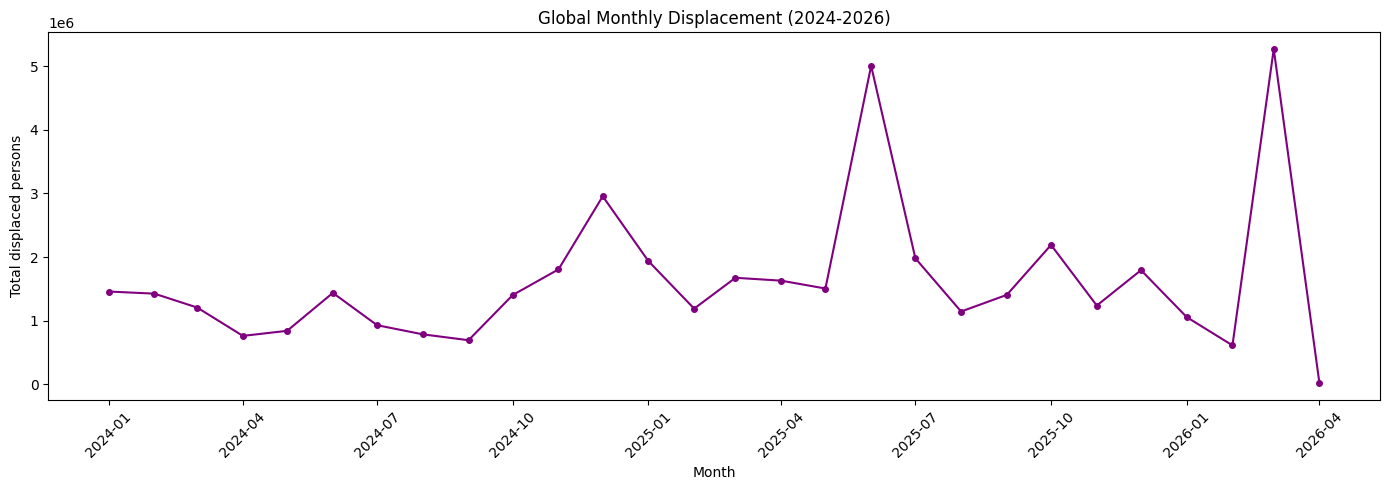

In [52]:
# Monthly displacement for 2024-2026 only
recent = df[pd.to_datetime(df['month']).dt.year >= 2024]
global_recent = recent.groupby('month')['monthly_displacement'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(global_recent['month']), global_recent['monthly_displacement'],
        color='purple', linewidth=1.5, marker='o', markersize=4)
ax.set_title('Global Monthly Displacement (2024-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Total displaced persons')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# Top displacement spikes for 2024-2026, showing country and value
recent = df[pd.to_datetime(df['month']).dt.year >= 2024].copy()

top_spikes = recent[['iso3', 'month', 'monthly_displacement']].sort_values('monthly_displacement', ascending=False).head(20)
top_spikes

,iso3,month,monthly_displacement
7389,IRN,2025-06-01,4.000000e+06
7398,IRN,2026-03-01,2.953846e+06
8898,LBN,2026-03-01,2.102447e+06
15183,SYR,2024-12-01,1.652118e+06
3384,COD,2025-01-01,1.447932e+06
3395,COD,2025-12-01,1.017874e+06
3383,COD,2024-12-01,9.670742e+05
3390,COD,2025-07-01,9.599976e+05
3393,COD,2025-10-01,9.503392e+05
3386,COD,2025-03-01,9.099468e+05


Examining the most extreme displacement spikes in 2024-2026 reveals that they are concentrated in a small number of countries. Iran (IRN) stands out with the two highest values in the entire dataset , 4 million in June 2025 and nearly 3 million in March 2026, despite having virtually no displacement history before this period. Lebanon (LBN) shows a similar pattern, with 2.1 million in March 2026. In contrast, COD's spikes are more consistent with its profile as a chronic crisis country, recording multiple months above 500,000-1,400,000 throughout 2024-2025. Syria (SYR) and South Sudan (SSD) show isolated but plausible spikes tied to specific escalation periods. The abrupt and historically unprecedented nature of the IRN and LBN spikes suggests these values should be treated with caution, as they may reflect data quality issues in recent IDMC records rather than genuine displacement events of this magnitude.

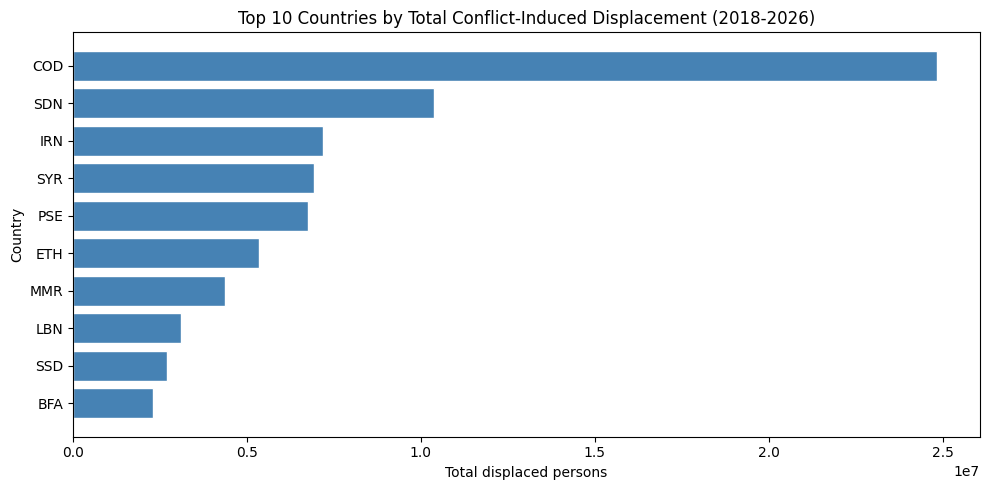

In [26]:
import matplotlib.pyplot as plt

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_disp.index[::-1], top10_disp.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 10 Countries by Total Conflict-Induced Displacement (2018-2026)')
ax.set_xlabel('Total displaced persons')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

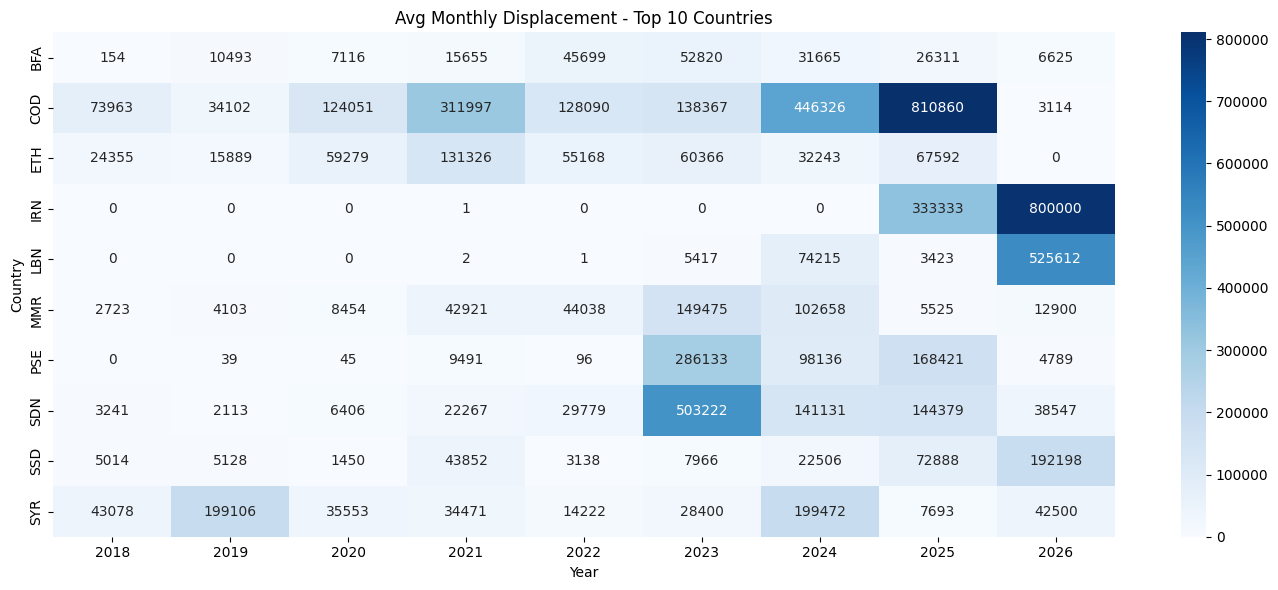

In [27]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10).index

yearly_disp = df[df['iso3'].isin(top10_disp)].groupby(['year', 'iso3'])['monthly_displacement'].mean().round(0)

pivot_disp = yearly_disp.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_disp, cmap='Blues', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Displacement - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap shows the average monthly conflict-induced displacement for the 10 countries with the highest cumulative totals over the study period. COD consistently leads throughout, peaking at over 810,000 displaced persons per month in 2025, reflecting a chronic and worsening displacement crisis Several countries show sudden escalations tied to specific events. Sudan (SDN) spikes in 2023 with the outbreak of civil war. Palestine (PSE) goes from near-zero to 286,000 monthly in 2022. Syria (SYR) shows the opposite pattern, high displacement in 2018-2019 that gradually declines as the conflict de-escalates. The most notable cases are Iran (IRN) and Lebanon (LBN), which show zero displacement until 2025, then surge to 800,000 and 525,000 respectively in 2026. These abrupt spikes warrant caution as they may reflect data quality issues rather than actual displacement at that scale.

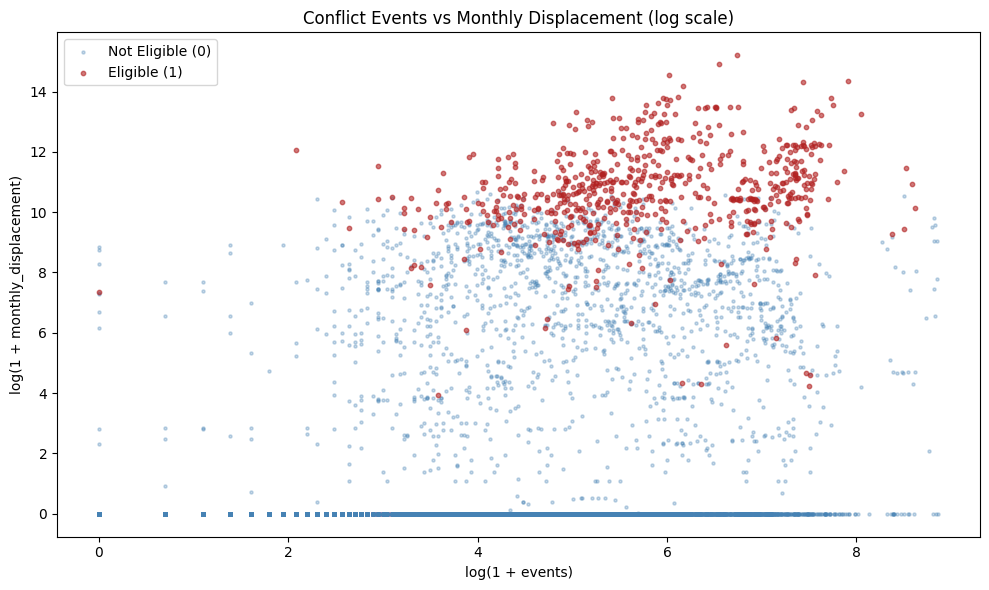

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

# Non-eligible
mask0 = df['allocation-eligible'] == 0
ax.scatter(np.log1p(df[mask0]['event_count']), np.log1p(df[mask0]['monthly_displacement']),
           alpha=0.3, color='steelblue', s=5, label='Not Eligible (0)')

# Eligible
mask1 = df['allocation-eligible'] == 1
ax.scatter(np.log1p(df[mask1]['event_count']), np.log1p(df[mask1]['monthly_displacement']),
           alpha=0.6, color='firebrick', s=10, label='Eligible (1)')

ax.set_title('Conflict Events vs Monthly Displacement (log scale)')
ax.set_xlabel('log(1 + events)')
ax.set_ylabel('log(1 + monthly_displacement)')
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot examines the relationship between conflict activity (ACLED events) and conflict-induced displacement (IDMC) at the country-month level, with both variables on a log scale. Each point represents a country-month observation, colored by allocation-eligible status. Countries that are allocation-eligible (red) cluster in the upper-right region of the chart, indicating that crisis months are characterized by simultaneously high conflict activity and high displacement. In contrast, non-eligible months (blue) are widely dispersed, with a large concentration along y=0, reflecting country-months where conflict events occur but produce no recorded displacement. This pattern suggests that while conflict and displacement are positively associated, not all conflict translates into displacement, the co-occurrence of both at high levels is what characterizes allocation-eligible situations. This reinforces the complementarity of ACLED and IDMC as predictors in the early warning model.

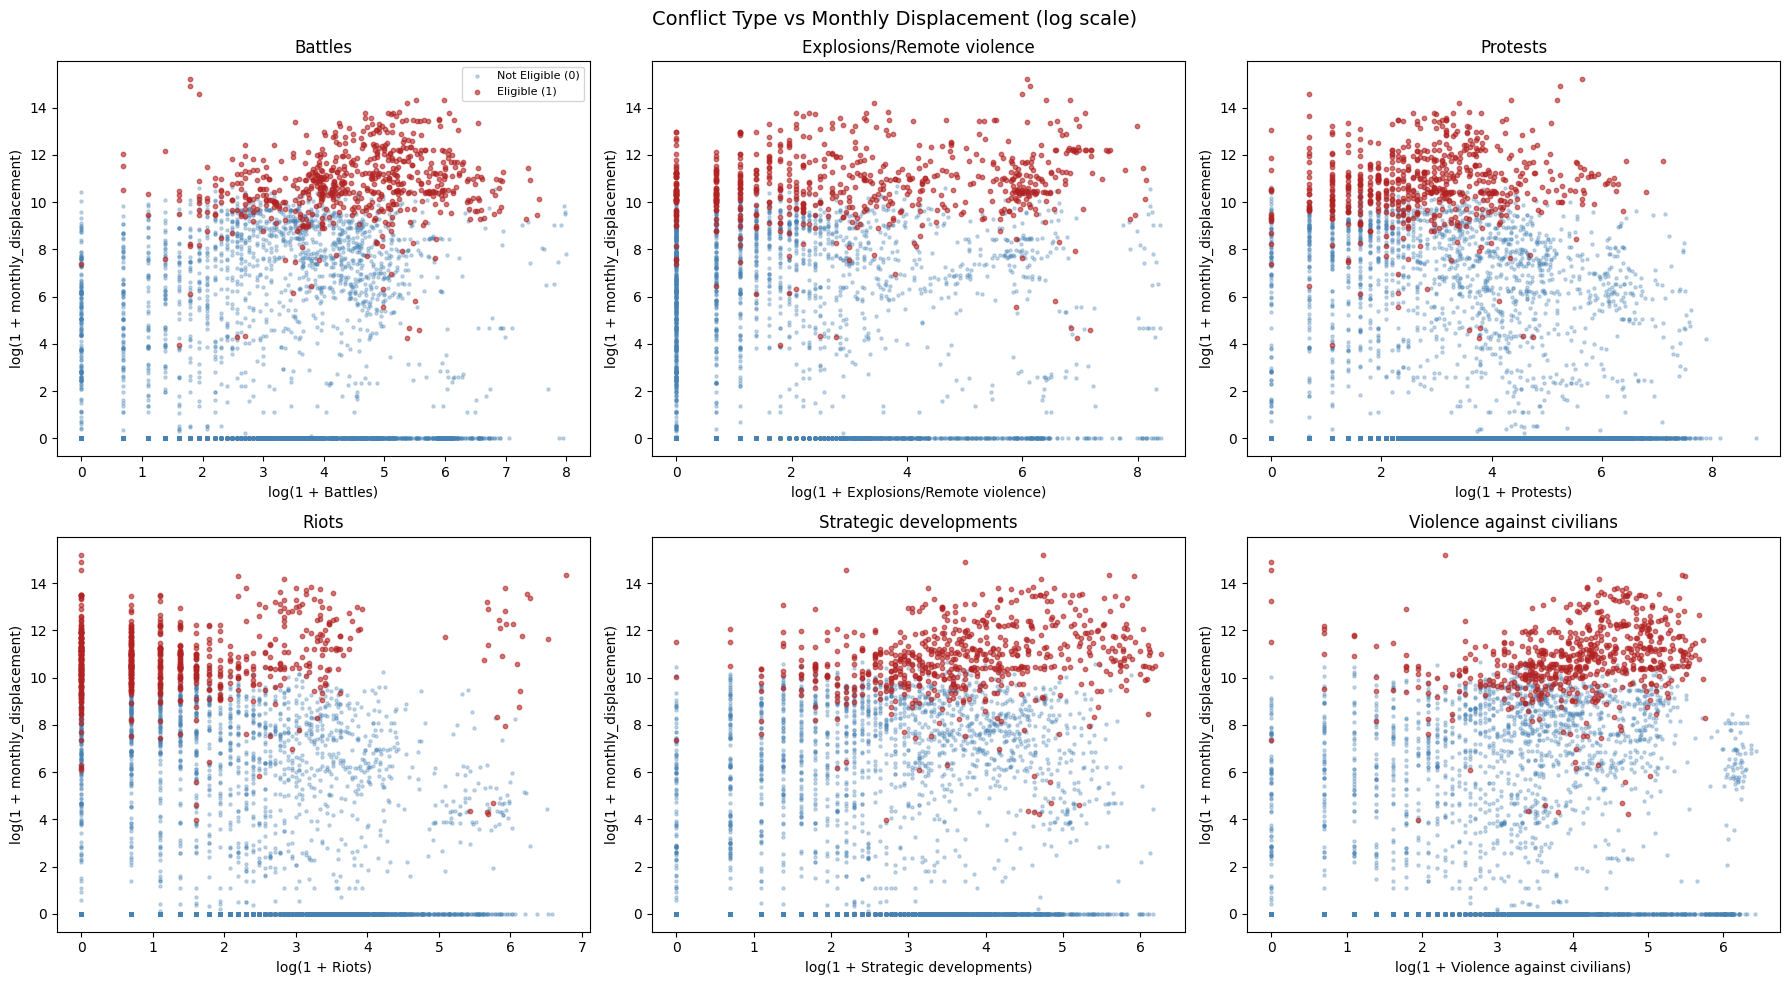

In [60]:
event_types = ['Battles', 'Explosions/Remote violence', 'Protests', 
               'Riots', 'Strategic developments', 'Violence against civilians']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Conflict Type vs Monthly Displacement (log scale)', fontsize=14)

mask0 = df['allocation-eligible'] == 0
mask1 = df['allocation-eligible'] == 1

for i, col in enumerate(event_types):
    ax = axes[i//3, i%3]
    
    ax.scatter(np.log1p(df[mask0][col]), np.log1p(df[mask0]['monthly_displacement']),
               alpha=0.3, color='steelblue', s=5, label='Not Eligible (0)')
    ax.scatter(np.log1p(df[mask1][col]), np.log1p(df[mask1]['monthly_displacement']),
               alpha=0.6, color='firebrick', s=10, label='Eligible (1)')
    
    ax.set_title(col)
    ax.set_xlabel(f'log(1 + {col})')
    ax.set_ylabel('log(1 + monthly_displacement)')
    
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

These graphics show that strategic dev,violence against civilians and battles show and more clear pattern between displacements and conflict type suggesting that these types of conflicts tend to motivate more displacements. This is line with what we observed before. Explosions/ remote violence do not show a pattern as clear as the others but we can see the difference between allocation elegible and the rest.

### HDX Signals 


In [29]:
# HDX base variables
hdx_cols = ['hdx_alert_Medium concern', 'hdx_alert_High concern', 'hdx_value']

print(df[hdx_cols].describe(include='all').round(2))

print(f"\nMissing values:")
print(df[hdx_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[hdx_cols].isnull().sum() / len(df) * 100).round(2))

       hdx_alert_Medium concern  hdx_alert_High concern   hdx_value
count                  17600.00                17600.00    17600.00
mean                       0.04                    0.02     2882.41
std                        0.21                    0.16    60668.23
min                        0.00                    0.00        0.00
25%                        0.00                    0.00        0.00
50%                        0.00                    0.00        0.00
75%                        0.00                    0.00        0.00
max                        3.00                    3.00  4008840.81

Missing values:
hdx_alert_Medium concern    0
hdx_alert_High concern      0
hdx_value                   0
dtype: int64

Missing percentage:
hdx_alert_Medium concern    0.0
hdx_alert_High concern      0.0
hdx_value                   0.0
dtype: float64


In [30]:
# Distribution of alert level
print(df['hdx_alert_Medium concern'].value_counts())
print(df['hdx_alert_High concern'].value_counts())

hdx_alert_Medium concern
0.0    16945
1.0      618
2.0       35
3.0        2
Name: count, dtype: int64
hdx_alert_High concern
0.0    17238
1.0      334
2.0       27
3.0        1
Name: count, dtype: int64


In [31]:
# Descriptive statistics for hdx_value
print(df['hdx_value'].describe().round(2))
print(f"\nMissing values: {df['hdx_value'].isnull().sum()}")
print(f"Missing percentage: {(df['hdx_value'].isnull().sum() / len(df) * 100).round(2)}%")

count      17600.00
mean        2882.41
std        60668.23
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      4008840.81
Name: hdx_value, dtype: float64

Missing values: 0
Missing percentage: 0.0%


In [32]:
# Find the observation with the maximum hdx_value
print(df[df['hdx_value'] == df['hdx_value'].max()][['iso3', 'month', 'hdx_alert_Medium concern', 'hdx_alert_High concern', 'hdx_value']])

     iso3      month  hdx_alert_Medium concern  hdx_alert_High concern  \
3042  CHN 2021-07-01                       1.0                     1.0   

         hdx_value  
3042  4.008841e+06  


This is possible an oultlier.

In [61]:
# Create hdx_alert_simple from existing columns
df['hdx_alert_simple'] = 'No alert'
df.loc[df['hdx_alert_Medium concern'] == True, 'hdx_alert_simple'] = 'Medium concern'
df.loc[df['hdx_alert_High concern'] == True, 'hdx_alert_simple'] = 'High concern'

# Crosstab
pd.crosstab(df['allocation-eligible'], df['hdx_alert_simple'], normalize='index').round(3) * 100

hdx_alert_simple,High concern,Medium concern,No alert
allocation-eligible,,,
0,1.5,2.8,95.7
1,13.4,14.0,72.6


HDX Signals coverage remains sparse: 95.7% of non-eligible country-months and 72.6% of eligible ones have no alert recorded. However, eligible countries are roughly 9 times more likely to have a "High concern" alert than non-eligible ones (13.4% vs 1.5%), and 5 times more likely to have "Medium concern" (14.0% vs 2.8%). This confirms that when HDX does flag a country, it strongly coincides with genuine crisis conditions, making it a useful, if limited, complementary signal.

*** Considerar observar/ tratar esa observación que es un outlier***

### EconAI — Conflict Risk Predictions

EconAI generates monthly country-level predictions of armed conflict. It produces four variables used in this project:

- `risk_3`: predicted probability of armed conflict onset in the next 3 months
- `risk_12`: predicted probability of armed conflict onset in the next 12 months
- `logfat_risk_3`: predicted fatalities in log scale at a 3-month horizon
- `logfat_risk_12`: predicted fatalities in log scale at a 12-month horizon

These variables are particularly valuable because they already embed conflict forecasting signal from an external model, making them strong candidate predictors for the early warning system. Unlike ACLED and IDMC which capture observed conflict, EconAI captures anticipated conflict risk,a more direct input for a predictive model.

In [28]:
# Descriptive statistics - EconAI variables
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

df[econai_cols].describe().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
count,17424.000,17424.000,17424.000,17424.000
mean,0.089,0.179,1.128,1.655
std,0.111,0.201,1.800,1.990
min,0.008,0.006,0.008,0.058
25%,0.025,0.037,0.050,0.281
50%,0.040,0.084,0.213,0.704
75%,0.095,0.242,1.282,2.358
max,0.560,0.822,8.906,8.569


In [29]:
# Missing values
print("Missing values:")
print(df[econai_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[econai_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
risk_3            176
risk_12           176
logfat_risk_3     176
logfat_risk_12    176
dtype: int64

Missing percentage:
risk_3            1.0
risk_12           1.0
logfat_risk_3     1.0
logfat_risk_12    1.0
dtype: float64


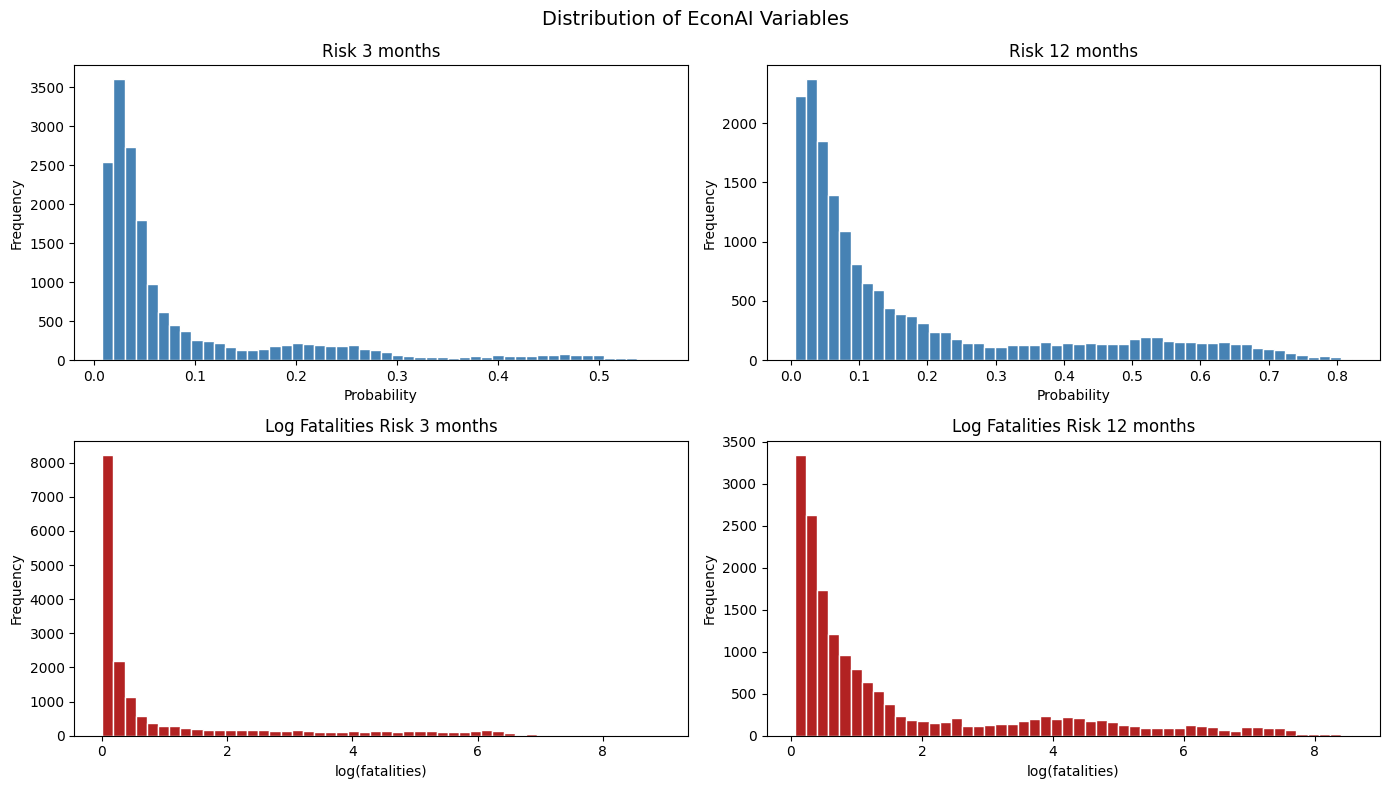

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of EconAI Variables', fontsize=14)

# risk_3
axes[0, 0].hist(df['risk_3'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Risk 3 months')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')

# risk_12
axes[0, 1].hist(df['risk_12'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Risk 12 months')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')

# logfat_risk_3
axes[1, 0].hist(df['logfat_risk_3'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Log Fatalities Risk 3 months')
axes[1, 0].set_xlabel('log(fatalities)')
axes[1, 0].set_ylabel('Frequency')

# logfat_risk_12
axes[1, 1].hist(df['logfat_risk_12'], bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Log Fatalities Risk 12 months')
axes[1, 1].set_xlabel('log(fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

All four EconAI variables show a strongly right-skewed distribution. For `risk_3` and `risk_12`, the majority of country-months receive very low conflict probabilities, concentrated near zero. 

In [31]:
# Top 10 countries by average risk_3, risk_12, logfat_risk_3, logfat_risk_12
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

for col in econai_cols:
    print(f"\n=== Top 10 Countries by avg {col} ===")
    print(df.groupby('iso3')[col].mean().nlargest(10).round(3))


=== Top 10 Countries by avg risk_3 ===
iso3
YEM    0.487
SYR    0.475
SOM    0.457
COD    0.456
AFG    0.430
SDN    0.427
IRQ    0.395
MLI    0.387
BFA    0.319
NER    0.309
Name: risk_3, dtype: float64

=== Top 10 Countries by avg risk_12 ===
iso3
SDN    0.734
YEM    0.728
COD    0.722
IRQ    0.683
AFG    0.680
SYR    0.674
SOM    0.624
MLI    0.618
ISR    0.597
PSE    0.597
Name: risk_12, dtype: float64

=== Top 10 Countries by avg logfat_risk_3 ===
iso3
AFG    6.739
SYR    6.697
YEM    6.290
SOM    6.158
COD    6.122
IRQ    5.883
SDN    5.797
NGA    5.545
MEX    5.404
MLI    5.336
Name: logfat_risk_3, dtype: float64

=== Top 10 Countries by avg logfat_risk_12 ===
iso3
AFG    7.577
SYR    7.454
YEM    7.270
SDN    7.131
SOM    7.081
COD    7.010
IRQ    6.793
PAK    6.181
MLI    6.135
NGA    5.698
Name: logfat_risk_12, dtype: float64


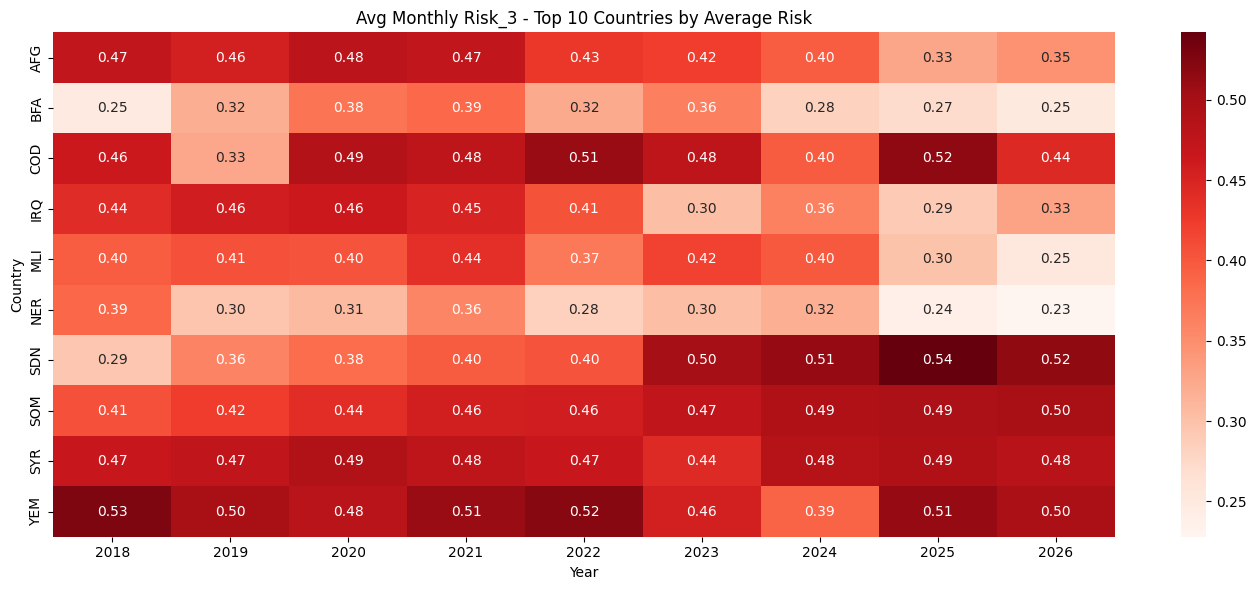

In [32]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average risk_3
top10_risk = df.groupby('iso3')['risk_3'].mean().nlargest(10).index

yearly_risk = df[df['iso3'].isin(top10_risk)].groupby(['year', 'iso3'])['risk_3'].mean().round(3)

pivot_risk = yearly_risk.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_risk, cmap='Reds', fmt='.2f', annot=True, ax=ax)
ax.set_title('Avg Monthly Risk_3 - Top 10 Countries by Average Risk')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap illustrates the average monthly risk_3 scores for the ten highest-risk countries. Most cells hover between 0.35 and 0.50 throughout the entire period, reflecting that EconAI assigns a persistent baseline risk to chronic conflict contexts like Yemen (YEM), Syria (SYR), and the Democratic Republic of the Congo (COD). Burkina Faso (BFA) starts at a lower baseline of 0.25 in 2018 and peaks at 0.39 in 2021, capturing the initial escalation of violence in the Sahel. Meanwhile, Sudan (SDN) exhibits the most distinct upward trend, rising from 0.29 in 2018 to a peak of 0.54 by 2025, consistent with the severe intensification of conflict in the region.

#### Part 2: Bivariate Analysis

This section examines how EconAI risk predictions behave in relation to `allocation-eligible`. The expectation is that countries meeting the CERF criteria should show systematically higher conflict risk scores, validating the predictive signal embedded in EconAI variables.

In [33]:
# Mean risk by allocation-eligible
df.groupby('allocation-eligible')[['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']].mean().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
allocation-eligible,,,,
0,0.079,0.162,0.965,1.484
1,0.365,0.626,5.493,6.234


The comparison of EconAI variables across allocation-eligible groups reveals a difference. Countries that are allocation-eligible show an average `risk_3` of 0.365 compared to 0.079 for non-eligible countries, a difference of more than four times. The same pattern holds for `risk_12` (0.626 vs 0.162).

For the log fatality predictions, the gap is even more pronounced. Eligible countries show a `logfat_risk_3` of 5.493. Non-eligible countries average 0.965 in log scale.

These results confirm that EconAI variables carry strong discriminative power between crisis and non-crisis country-months, making them valuable predictors in the early warning model. 

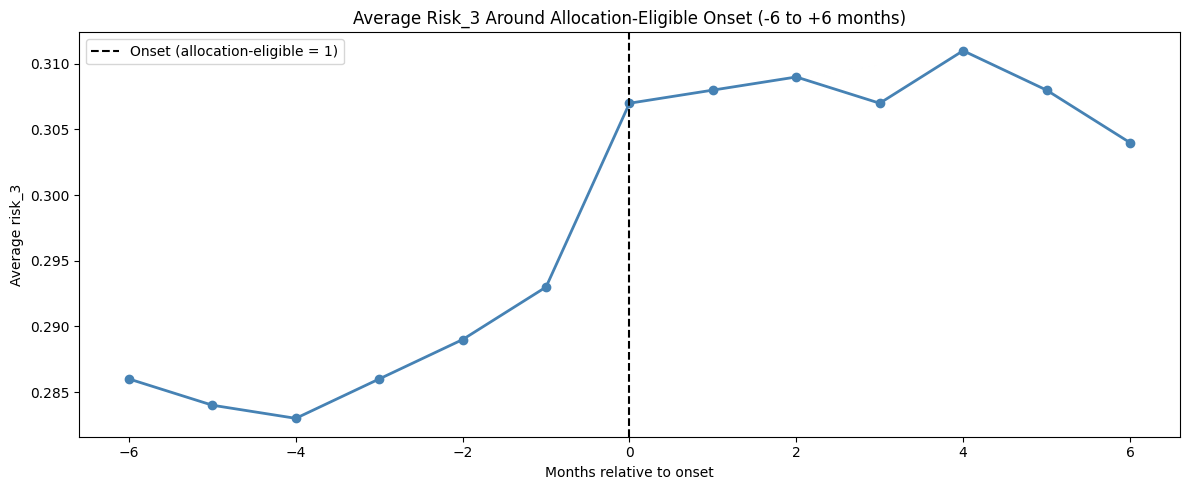

In [34]:
# Window around onset for risk_3
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

windows_risk3 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk3.append({'months_to_onset': t, 
                                  'risk_3': match['risk_3'].values[0]})

window_df_risk3 = pd.DataFrame(windows_risk3)
avg_risk3 = window_df_risk3.groupby('months_to_onset')['risk_3'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk3.index, avg_risk3.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_3 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_3')
ax.legend()
plt.tight_layout()
plt.show()

`risk_3` shows a steady upward trend starting from t-4, rising from 0.28 to 0.305 at the onset. Unlike fatalities, where the signal was concentrated in the last 2 months before onset, EconAI anticipates the crisis gradually and consistently from 4 months in advance. After the onset, risk remains elevated around 0.31, reflecting that conflict contexts persist once they begin. This earlier and smoother anticipation pattern strengthens the case for including `risk_3` as a predictor, as it provides a longer warning window than observed conflict variables like ACLED fatalities.

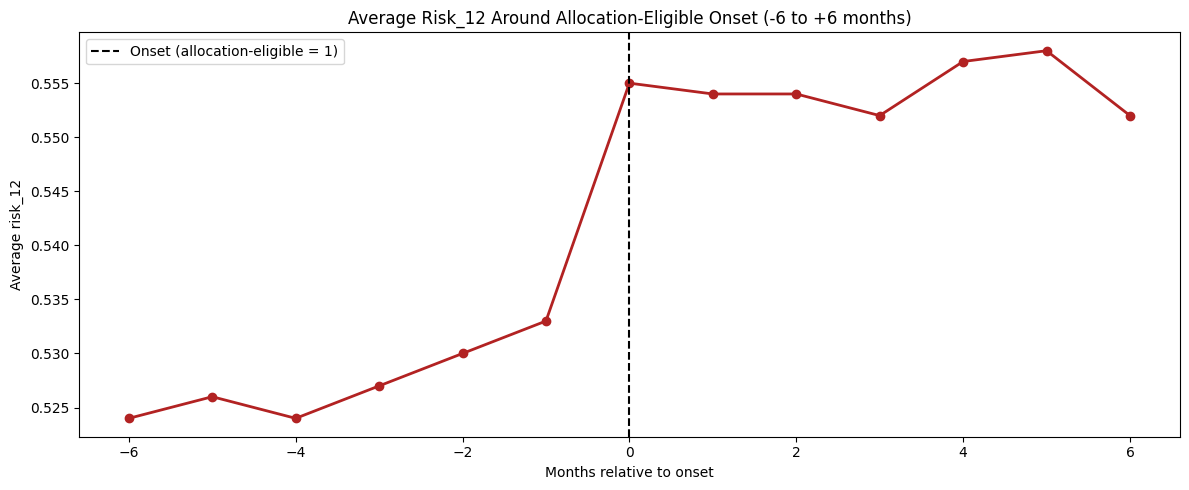

In [35]:
# Window around onset for risk_12
windows_risk12 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk12.append({'months_to_onset': t,
                                   'risk_12': match['risk_12'].values[0]})

window_df_risk12 = pd.DataFrame(windows_risk12)
avg_risk12 = window_df_risk12.groupby('months_to_onset')['risk_12'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk12.index, avg_risk12.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_12 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_12')
ax.legend()
plt.tight_layout()
plt.show()

`risk_12` follows the same upward pattern as `risk_3`, rising from 0.525 at t-6 to 0.555 at the onset and stabilizing around 0.56 afterwards. The key difference is that baseline values are higher throughout, as the 12-month horizon naturally captures more accumulated conflict risk. Both variables confirm that EconAI anticipates allocation-eligible crises from at least 4 months in advance, making them strong early warning predictors.

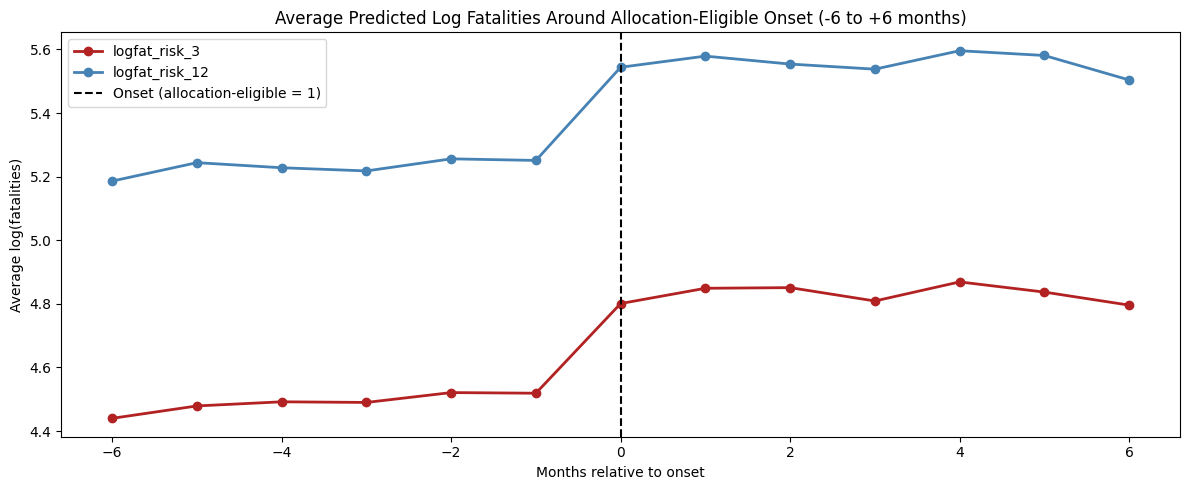

In [36]:
# Window around onset for logfat_risk_3 and logfat_risk_12
windows_logfat = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_logfat.append({
                'months_to_onset': t,
                'logfat_risk_3': match['logfat_risk_3'].values[0],
                'logfat_risk_12': match['logfat_risk_12'].values[0]
            })

window_df_logfat = pd.DataFrame(windows_logfat)
avg_logfat = window_df_logfat.groupby('months_to_onset')[['logfat_risk_3', 'logfat_risk_12']].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_logfat.index, avg_logfat['logfat_risk_3'], color='firebrick', linewidth=2, marker='o', label='logfat_risk_3')
ax.plot(avg_logfat.index, avg_logfat['logfat_risk_12'], color='steelblue', linewidth=2, marker='o', label='logfat_risk_12')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Predicted Log Fatalities Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average log(fatalities)')
ax.legend()
plt.tight_layout()
plt.show()

There is a clear pattern with these variables. The months before the crisis, specially since month -6 , there is an stable trend, showing a peak the month 0. We should pay attention to short term patterns.

### INFORM Risk Index

The INFORM Risk Index is a composite indicator that measures the risk of humanitarian crisis and disaster at the country level based on three dimensions:

- `INFORM`: composite risk score (0-10 scale)
- `HA`: Hazard & Exposure — likelihood of a hazardous event occurring
- `VU`: Vulnerability — susceptibility of people to the effects of hazards
- `CC`: Coping Capacity — ability of governments and communities to manage disasters

Unlike ACLED and IDMC which capture observed conflict, INFORM measures structural and chronic risk factors. A country with a high INFORM score is not necessarily in active conflict, but is more vulnerable to humanitarian crises when shocks occur. This makes it a complementary predictor to more dynamic variables like EconAI or ACLED.

In [42]:
# INFORM variables
inform_cols = ['INFORM', 'VU', 'CC', 'HA']

print(df[inform_cols].describe().round(2))
print(f"\nMissing values:")
print(df[inform_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[inform_cols].isnull().sum() / len(df) * 100).round(2))

        INFORM        VU        CC        HA
count  17600.0  17600.00  17600.00  17600.00
mean       3.8      3.78      4.46      3.69
std        1.8      1.96      1.95      2.24
min        0.4      0.30      0.80      0.10
25%        2.4      2.20      2.90      2.00
50%        3.7      3.50      4.40      3.20
75%        5.0      5.20      6.00      5.20
max        9.2      9.40      9.50      9.20

Missing values:
INFORM    0
VU        0
CC        0
HA        0
dtype: int64

Missing percentage:
INFORM    0.0
VU        0.0
CC        0.0
HA        0.0
dtype: float64


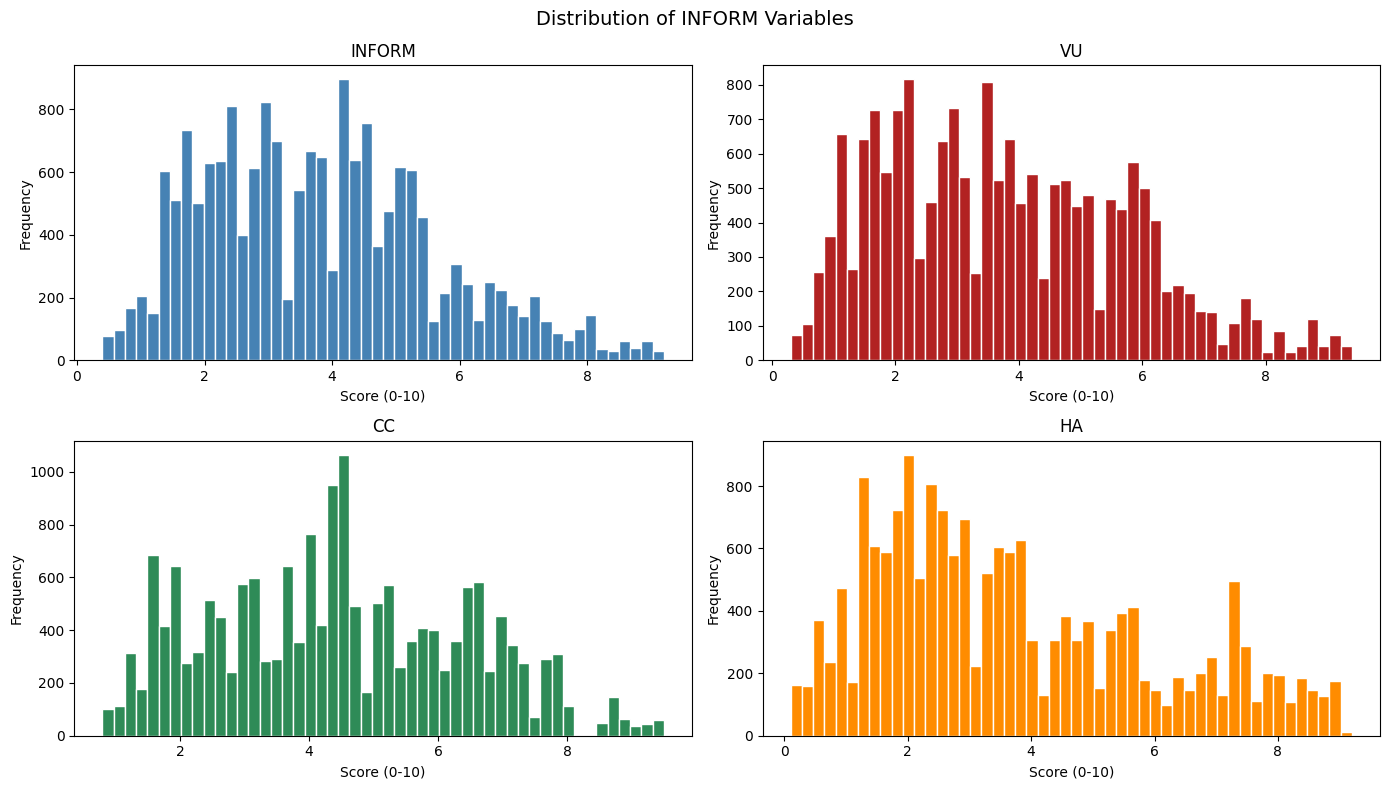

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of INFORM Variables', fontsize=14)

colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

for i, col in enumerate(inform_cols):
    ax = axes[i//2, i%2]
    ax.hist(df[col].dropna(), bins=50, color=colors[i], edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Unlike ACLED and IDMC, INFORM variables show no extreme skew , scores are distributed across the full 0-10 scale, reflecting structural differences between countries rather than event-driven spikes. `INFORM` and `CC` are concentrated in the mid-range (2-5), while `VU` is more uniformly distributed. `HA` shows a bimodal pattern, suggesting two distinct groups of countries, those with low hazard exposure and those with very high exposure.

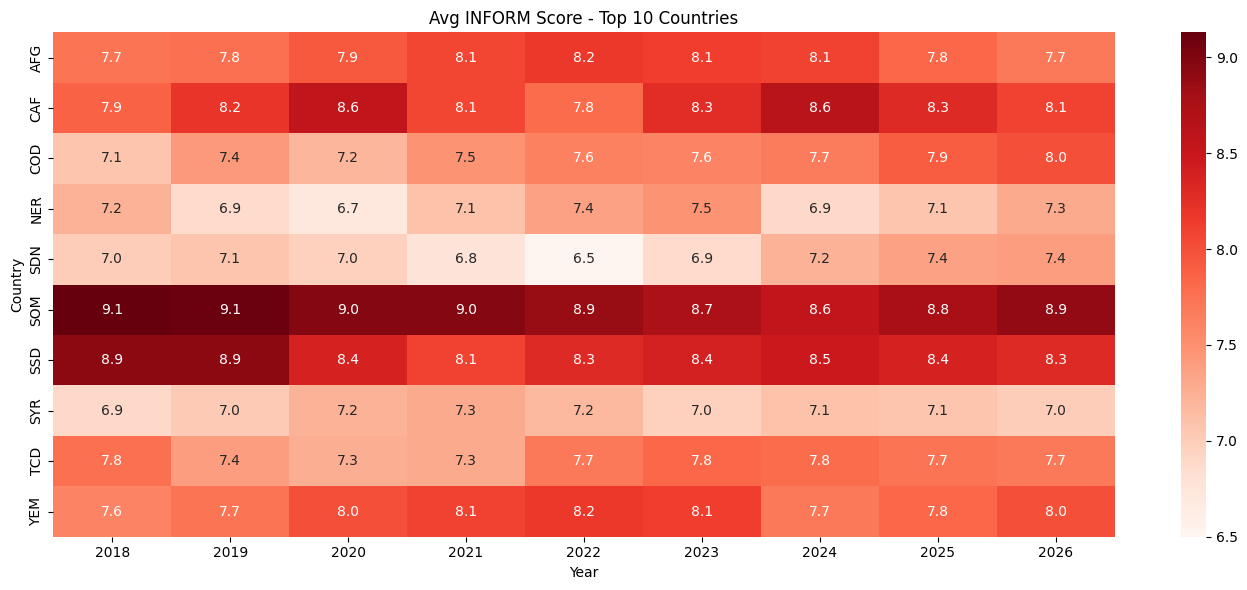

In [44]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average INFORM score
top10_inform = df.groupby('iso3')['INFORM'].mean().nlargest(10).index

yearly_inform = df[df['iso3'].isin(top10_inform)].groupby(['year', 'iso3'])['INFORM'].mean().round(2)

pivot_inform = yearly_inform.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_inform, cmap='Reds', fmt='.1f', annot=True, ax=ax)
ax.set_title('Avg INFORM Score - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

#### Part 2: Bivariate Analysis
This section examines whether countries that are allocation-eligible show systematically higher INFORM scores. Since INFORM captures structural vulnerability rather than active conflict, the expectation is that eligible countries present higher risk scores across all four dimensions, confirming that chronic vulnerability is a precondition for humanitarian crises.

In [45]:
# Mean INFORM variables by allocation-eligible
df.groupby('allocation-eligible')[['INFORM', 'VU', 'CC', 'HA']].mean().round(2)

,INFORM,VU,CC,HA
allocation-eligible,,,,
0,3.68,3.66,4.37,3.56
1,7.04,7.14,6.92,7.25


In [69]:
# Descriptive statistics for INFORM subcomponents - only allocation-eligible = 1
df[df['allocation-eligible'] == 1][['INFORM', 'VU', 'CC', 'HA']].describe().round(2)

,INFORM,VU,CC,HA
count,627.00,627.00,627.00,627.00
mean,7.04,7.14,6.92,7.25
std,1.00,1.16,1.36,1.32
min,2.80,1.70,2.20,2.10
25%,6.70,6.50,6.30,6.45
50%,7.10,7.30,6.70,7.30
75%,7.70,7.70,8.00,8.30
max,8.90,9.30,9.50,9.20


Among allocation-eligible country-months, all four INFORM components are concentrated at high levels (means between 6.9 and 7.25, out of 10), with relatively low variation (std around 1-1.4). This confirms that crisis countries are not only structurally vulnerable but consistently so , values rarely fall below 6.5 at the 25th percentile. `HA` (Hazard & Exposure) and `VU` (Vulnerability) show the highest averages, suggesting that exposure to risk and underlying vulnerability are slightly more pronounced than coping capacity limitations among eligible countries.

Total onsets: 106


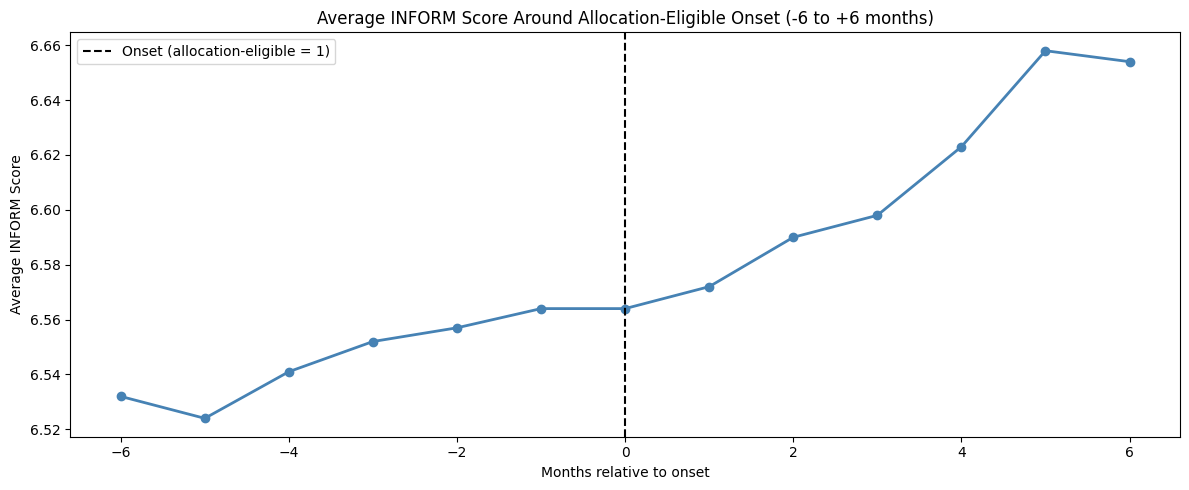

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Build onset
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()
print(f"Total onsets: {len(onset)}")

# Window around onset for INFORM
windows_inform = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_inform.append({'months_to_onset': t,
                                   'INFORM': match['INFORM'].values[0]})

window_df_inform = pd.DataFrame(windows_inform)
avg_inform = window_df_inform.groupby('months_to_onset')['INFORM'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_inform.index, avg_inform.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average INFORM Score Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average INFORM Score')
ax.legend()
plt.tight_layout()
plt.show()

The INFORM score rises from 6.52 at t-6 to 6.56 at the onset, and continues increasing after the crisis begins, reaching 6.66 at t+5. This suggests that allocation-eligible countries are not only structurally more vulnerable before the crisis, but that their risk scores tend to worsen once the crisis is underway. Unlike EconAI and ACLED, the variation is small in magnitude , INFORM captures chronic structural risk that changes slowly over time, rather than pronounced conflict signals. This confirms its role as a background risk indicator rather than an early warning trigger.

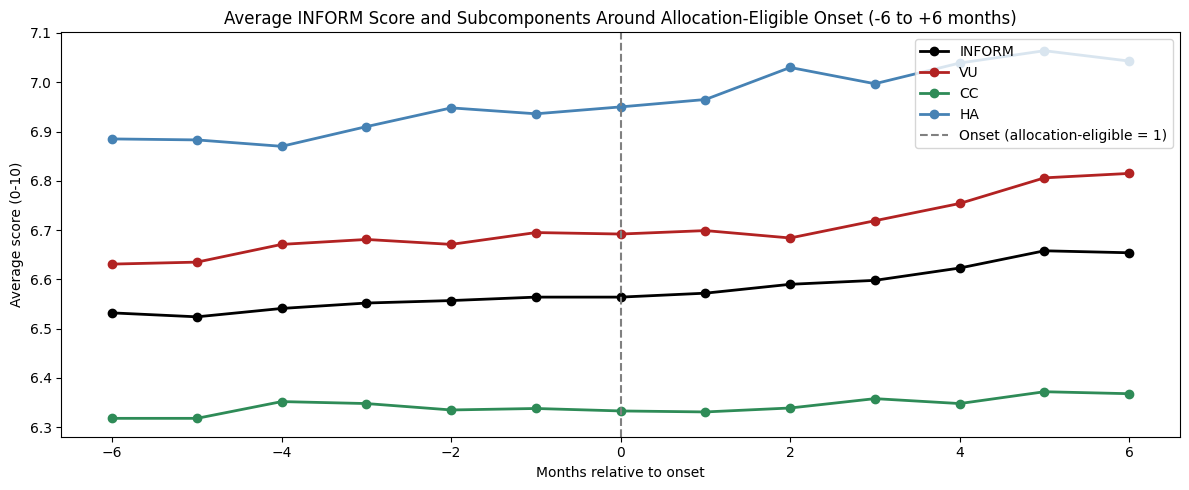

In [66]:
# Window around onset for all INFORM components
inform_cols = ['INFORM', 'VU', 'CC', 'HA']

windows_inform_sub = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            entry = {'months_to_onset': t}
            for col in inform_cols:
                entry[col] = match[col].values[0]
            windows_inform_sub.append(entry)

window_df_inform_sub = pd.DataFrame(windows_inform_sub)
avg_inform_sub = window_df_inform_sub.groupby('months_to_onset')[inform_cols].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))

colors = {'INFORM': 'black', 'VU': 'firebrick', 'CC': 'seagreen', 'HA': 'steelblue'}

for col in inform_cols:
    ax.plot(avg_inform_sub.index, avg_inform_sub[col], marker='o', label=col, color=colors[col], linewidth=2)

ax.axvline(x=0, color='gray', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average INFORM Score and Subcomponents Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average score (0-10)')
ax.legend()
plt.tight_layout()
plt.show()

The behavior of the index and its subcomponents is relatively stable. The HA shows elevated levels, suggesting that after the crisis, the probability of a hazardous event occurring increases.

### GENERAL ANALYSIS

To provide a comprehensive view of how all data sources behave simultaneously, this section presents an interactive visualization combining the key variables from each source: ACLED fatalities and event count, IDMC conflict-induced displacement, EconAI risk score (`risk_3`), INFORM Risk Index, and HDX Signals alert levels.

Since these variables operate on very different scales , fatalities can reach thousands while risk scores are bounded between 0 and 1 , all variables were normalized to a 0-1 range to allow direct visual comparison. The red shaded areas indicate months where the country is allocation-eligible, and the dots at the top represent HDX alerts (orange = Medium concern, red = High concern).

The dropdown allows selecting any of the 176 countries in the dataset, making it possible to compare the dynamics of chronic conflict contexts, sudden escalations, and peaceful countries across the full study period.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def plot_country(country):
    country_df = df[df['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible shading
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.15, linewidth=4)

    # HDX alerts
    hdx_medium = country_df[country_df['hdx_alert_Medium concern'] == True]['month']
    hdx_high = country_df[country_df['hdx_alert_High concern'] == True]['month']
    ax1.scatter(hdx_medium, [1.05]*len(hdx_medium), color='orange', s=60, zorder=5, label='HDX Medium')
    ax1.scatter(hdx_high, [1.05]*len(hdx_high), color='red', s=60, zorder=5, label='HDX High')

    ax1.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

countries = sorted(df['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='UKR', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', index=164, options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', …

<function __main__.plot_country(country)>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

def plot_country(country):
    country_df = df[df['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    
    # EconAI - all 4 variables
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['risk_12'],
             color='dimgray', linewidth=1.5, linestyle='--', label='Risk_12')
    ax1.plot(country_df['month'], country_df['logfat_risk_3'] / 10,
             color='darkred', linewidth=1.2, linestyle='-.', label='LogFat_3 (norm)')
    ax1.plot(country_df['month'], country_df['logfat_risk_12'] / 10,
             color='salmon', linewidth=1.2, linestyle='-.', label='LogFat_12 (norm)')
    
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible shading
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.15, linewidth=4)

    # HDX alerts
    hdx_medium = country_df[country_df['hdx_alert_Medium concern'] == True]['month']
    hdx_high = country_df[country_df['hdx_alert_High concern'] == True]['month']
    ax1.scatter(hdx_medium, [1.05]*len(hdx_medium), color='orange', s=60, zorder=5, label='HDX Medium')
    ax1.scatter(hdx_high, [1.05]*len(hdx_high), color='red', s=60, zorder=5, label='HDX High')

    ax1.legend(loc='upper left', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

countries = sorted(df['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='UKR', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', index=164, options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', …

<function __main__.plot_country(country)>

The following three countries were selected as illustrative case studies because they represent the top 3 countries in the allocation elegible variable. As that is our target variable, we want to analyze the dynamics of those countries and check any relevant patterns. 

### COD — Democratic Republic of Congo
COD represents a **chronic crisis** context. The country is allocation-eligible for almost the entire study period, with Risk_3 at maximum (1.0) since 2019 and  INFORM consistently high (~0.7). Fatalities and displacement fluctuate but never drop to zero, and HDX alerts appear regularly throughout. This is a case where all signals are permanently elevated, the challenge for the model is not detecting the onset but distinguishing periods of acute escalation from the
chronic baseline.

### ETH — Ethiopia
ETH shows a **recurring crisis** pattern with multiple allocation-eligible periods throughout the study. The most notable escalation occurs in late 2020-2021, coinciding with the Tigray conflict, where fatalities and displacement spike simultaneously to their maximum values. Risk_3 rises sharply ahead of this onset, suggesting EconAI anticipated the escalation. After 2022 the crisis partially de-escalates but allocation-eligible periods persist, reflecting ongoing instability in multiple regions. HDX alerts appear consistently, with High concern signals concentrated around the peak conflict periods.

### MMR — Myanmar
MMR illustrates a **coup-driven crisis**. Before February 2021 all signals are relatively low despite Risk_3 fluctuating around 0.6. The military coup triggers an immediate and sustained escalation , event count, fatalities and displacement all spike together and allocation-eligible periods begin almost immediately after. Risk_3 jumps to near 1.0 and remains there, and HDX High concern alerts become frequent. This case shows how a sudden political shock can rapidly transition a country from stable to chronic crisis, with most signals reacting simultaneously rather than sequentially.